In [ ]:
from data_utils import *


DATA_ROOT = "../outputs/combined/"
FIGURE_ROOT = Path("../outputs/plots/pca")
N_RUNS = 100
N_EXAMPLES = 50000

model_df = get_model_df(DATA_ROOT)
MODEL_SUBSET = [
    {"key": "lottery_8ae667adac9b690a88b522e85f1388c8"},
    {"key": "lottery_cf40a5a8bbe4f285b8fe317c1aa95dd5"},
    {"key": "lottery_06562e05cda1bf840ee146490815ed82"},
    {"key": "lottery_9dc2b8dfff54c4da57570d7b391dcccd"},
]
model_df = multi_filter_df(model_df, MODEL_SUBSET)
model_df

/home/devin/miniconda3/envs/ml-torch/lib/python3.7/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,model_key,dataset_key,Model,Dataset,Task,Parameters,path,key,n_replicates
5,cifar_resnet_20,cifar10,ResNet-20,CIFAR-10,CIFAR-10/ResNet-20,272474,../outputs/combined/lottery_8ae667adac9b690a88...,lottery_8ae667adac9b690a88b522e85f1388c8,100
8,cifar_vgg_16,cifar10,VGG-16,CIFAR-10,CIFAR-10/VGG-16,14728266,../outputs/combined/lottery_cf40a5a8bbe4f285b8...,lottery_cf40a5a8bbe4f285b8fe317c1aa95dd5,100
1,cifar_vgg_16,cifar100,VGG-16,CIFAR-100,CIFAR-100/VGG-16,14728266,../outputs/combined/lottery_06562e05cda1bf840e...,lottery_06562e05cda1bf840ee146490815ed82,100
6,cifar_resnet_20,cifar100,ResNet-20,CIFAR-100,CIFAR-100/ResNet-20,272474,../outputs/combined/lottery_9dc2b8dfff54c4da57...,lottery_9dc2b8dfff54c4da57570d7b391dcccd,100


In [2]:
SELECTED_SCORES = [
    {"key": "loss",
    "Method": "Training",
    "Type": ""},
    {"key": "margin",
    "Method": "Training",
    "Type": "",
    "Epoch": 160},
    {"key": "carlini_conf"},
    {"key": "batch_countforget",
    "Method": "Training",
    "Type": "",
    "Epoch": 160},
    {"key": "el2n",
    "Method": "One Step",
    "Type": "",
    "Epoch": 20},
    {"key": "classvog",
    "Method": "Training",
    "Type": "",
    "Epoch": 160},
    {"key": "selfproto",
    "Method": "One Step",
    "Type": "",
    "Epoch": 160},
    {"key": "pd",
    "Method": "One Step",
    "Type": "",
    "Epoch": 160},
    {"key": "carlini_ret"},
]

ALL_SCORES = [
    {"key": "carlini_agr"},
    {"key": "ddd",
    "Method": "Ensemble",
    "Type": "",
    "Epoch": 160},
    {"key": "ddd",
    "Method": "Ensemble",
    "Type": "",
    "Epoch": 20},
    {"key": "acc",
    "Method": "Training",
    "Type": "",
    "Epoch": 160},
    {"key": "acc",
    "Method": "One Step",
    "Type": "",
    "Epoch": 20},
    {"key": "loss",
    "Method": "Training",
    "Type": ""},
    {"key": "margin",
    "Method": "Training",
    "Type": "",
    "Epoch": 160},
    {"key": "conf",
    "Method": "Training",
    "Type": "",
    "Epoch": 160},
    {"key": "maxconf",
    "Method": "Training",
    "Type": "",
    "Epoch": 160},
    {"key": "carlini_conf"},
    {"key": "batch_countforget",
    "Method": "Training",
    "Type": "",
    "Epoch": 160},
    {"key": "countforget",
    "Method": "Training",
    "Type": "",
    "Epoch": 160},
    {"key": "batch_firstlearn",
    "Method": "Training",
    "Type": "",
    "Epoch": 160},
    {"key": "firstlearn",
    "Method": "Training",
    "Type": "",
    "Epoch": 160},
    {"key": "batch_firstunforgettable",
    "Method": "Training",
    "Type": "",
    "Epoch": 160},
    {"key": "firstunforgettable",
    "Method": "Training",
    "Type": "",
    "Epoch": 160},
    {"key": "batch_unforgettable",
    "Method": "Training",
    "Type": "",
    "Epoch": 160},
    {"key": "unforgettable",
    "Method": "Training",
    "Type": "",
    "Epoch": 160},
    {"key": "el2n",
    "Method": "One Step",
    "Type": "",
    "Epoch": 20},
    {"key": "el2n",
    "Method": "Training",
    "Type": "",
    "Epoch": 160},
    {"key": "grand",
    "Method": "One Step",
    "Type": "",
    "Epoch": 20},
    {"key": "grand",
    "Method": "One Step",
    "Type": "",
    "Epoch": 160},
    {"key": "classvog",
    "Method": "Training",
    "Type": "",
    "Epoch": 160},
    {"key": "lossvog",
    "Method": "Training",
    "Type": "",
    "Epoch": 160},
    {"key": "proto",
    "Method": "One Step",
    "Type": "",
    "Epoch": 160},
    {"key": "proto",
    "Method": "One Step",
    "Type": "",
    "Epoch": 20},
    {"key": "selfproto",
    "Method": "One Step",
    "Type": "",
    "Epoch": 160},
    {"key": "selfproto",
    "Method": "One Step",
    "Type": "",
    "Epoch": 20},
    {"key": "swav_selfproto"},
    {"key": "pd",
    "Method": "One Step",
    "Type": "",
    "Epoch": 160},
    {"key": "pd",
    "Method": "One Step",
    "Type": "",
    "Epoch": 20},
    {"key": "carlini_ret"},
    {"key": "carlini_adv"},
    {"key": "carlini_priv"},
    {"key": "memorization"},
    {"key": "memorization_inception"},
]

In [ ]:
from sklearn.preprocessing import quantile_transform
from sklearn.decomposition import PCA
import matplotlib

# preprocessing
def preprocess(x):
    if len(x.shape) == 1:  # assume shape (examples,)
        x = x.reshape(-1, 1)
    else:  # assume shape (features, examples)
        x = x.T
    return quantile_transform(x, n_quantiles=len(x), output_distribution="normal")


# PCA transform
def pca_transform(scores):
    scores = np.concatenate([preprocess(score) for score in scores], axis=1)
    pca = PCA()
    pca.fit(scores)
    transformed = pca.transform(scores)
    return pca


def make_largest_coefficient_positive(pca_components):
    output = [-1 * x if x[np.argmax(np.abs(x))] < 0 else x for x in pca_components]
    return np.stack(output, axis=0)


def plot_pca(scores, name):
    values = [np.mean(x, axis=0) if row["Method"] != "Ensemble" else x for row, x in scores]
    score_names = [("$-1 \\times$" if row["is_inverted"] else "") + row["Full Name"] for row, _ in scores]
    
    pca = pca_transform(values)
    max_components = min(14, np.searchsorted(np.cumsum(pca.explained_variance_ratio_), 0.95) + 1)

    fig = plt.figure()
    grid = matplotlib.gridspec.GridSpec(2, 1, figure=fig, height_ratios=[len(score_names), 2])
    component_names = [f"PCA {i+1}" for i in range(len(score_names))]

    # coefficients of components
    ax = fig.add_subplot(grid[0, 0])
    components = make_largest_coefficient_positive(pca.components_)
    sns.heatmap(components[:max_components].T, xticklabels=component_names[:max_components], yticklabels=score_names, annot=True, center=0, vmin=-1, vmax=1, ax=ax, fmt="0.2f", cbar_kws={"shrink": min(1, 10 / len(score_names))})

    # explained variance
    ax = fig.add_subplot(grid[1, 0])
    df = pd.DataFrame({"Component": component_names, "Explained variance ratio": pca.explained_variance_ratio_})
    ax = df.set_index("Component").T.plot.barh(stacked=True, ax=ax, legend=False)
    ax.set_xlabel("Fraction of total variance")
    for container, label in zip(ax.containers, component_names):
        if container[0].get_width() < 0.1:
            label = label.split(" ")[1]
        if container[0].get_width() > 0.02:
            ax.bar_label(container, labels=[label], label_type='center')

    # save and show
    save_fig(FIGURE_ROOT, "pca", name, figsize=(5 + max_components * 0.6, len(score_names) * 0.5 + 2))

model_key                                         cifar_resnet_20
dataset_key                                               cifar10
Model                                                   ResNet-20
Dataset                                                  CIFAR-10
Task                                           CIFAR-10/ResNet-20
Parameters                                                 272474
path            ../outputs/combined/lottery_8ae667adac9b690a88...
key                      lottery_8ae667adac9b690a88b522e85f1388c8
n_replicates                                                  100
Name: 5, dtype: object
Unable to load memorization: Combination does not exist: , cifar10
Saving figure to ../outputs/plots/pca/CIFAR-10-ResNet-20_selected_pca.pdf


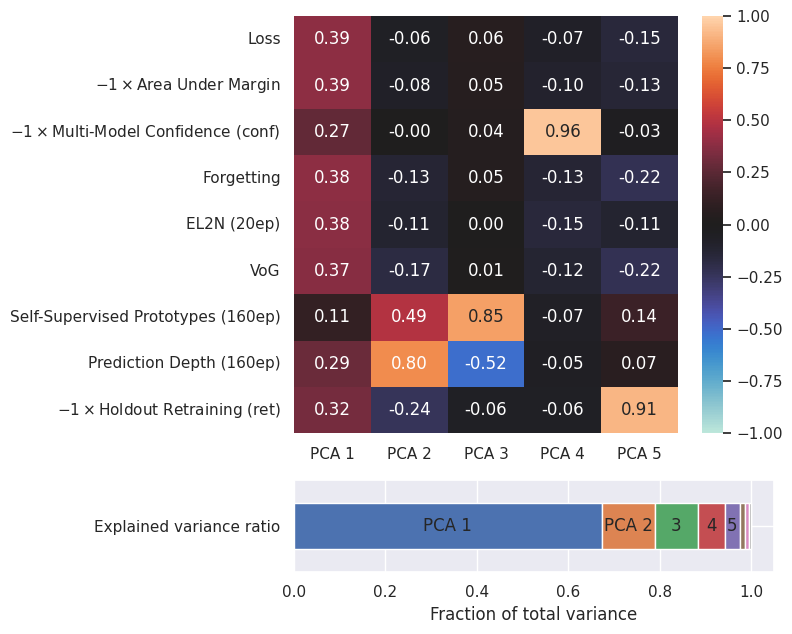

Saving figure to ../outputs/plots/pca/CIFAR-10-ResNet-20_selected_plus_std_pca.pdf


<Figure size 640x480 with 0 Axes>

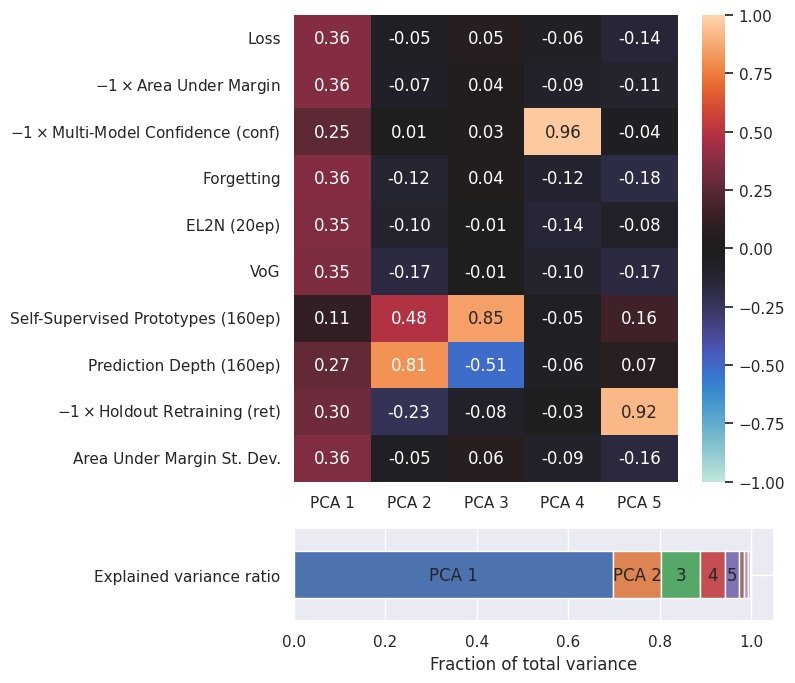

Saving figure to ../outputs/plots/pca/CIFAR-10-ResNet-20_selected_plus_std_pca.pdf


<Figure size 640x480 with 0 Axes>

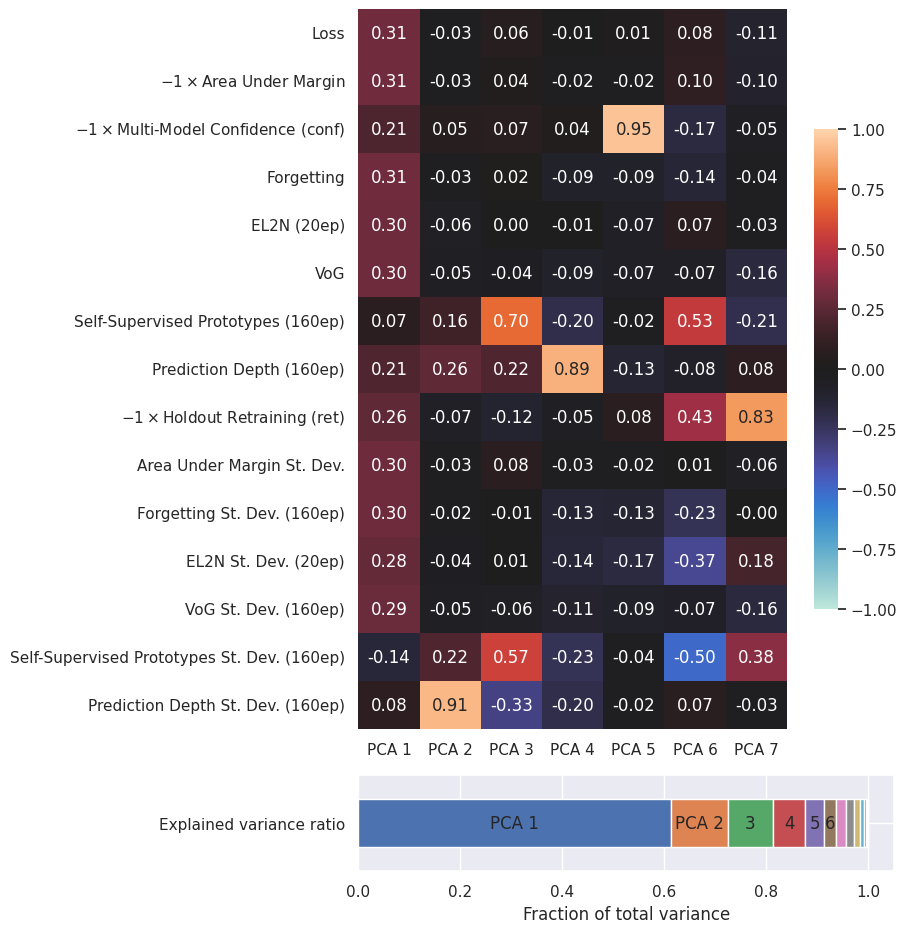

Columns: [Path, Replicate, Epoch, Method, Short Name, Full Name, Type, key, array, is_fuzzed, is_inverted]
Index: []
Saving figure to ../outputs/plots/pca/CIFAR-10-ResNet-20_pca.pdf


<Figure size 640x480 with 0 Axes>

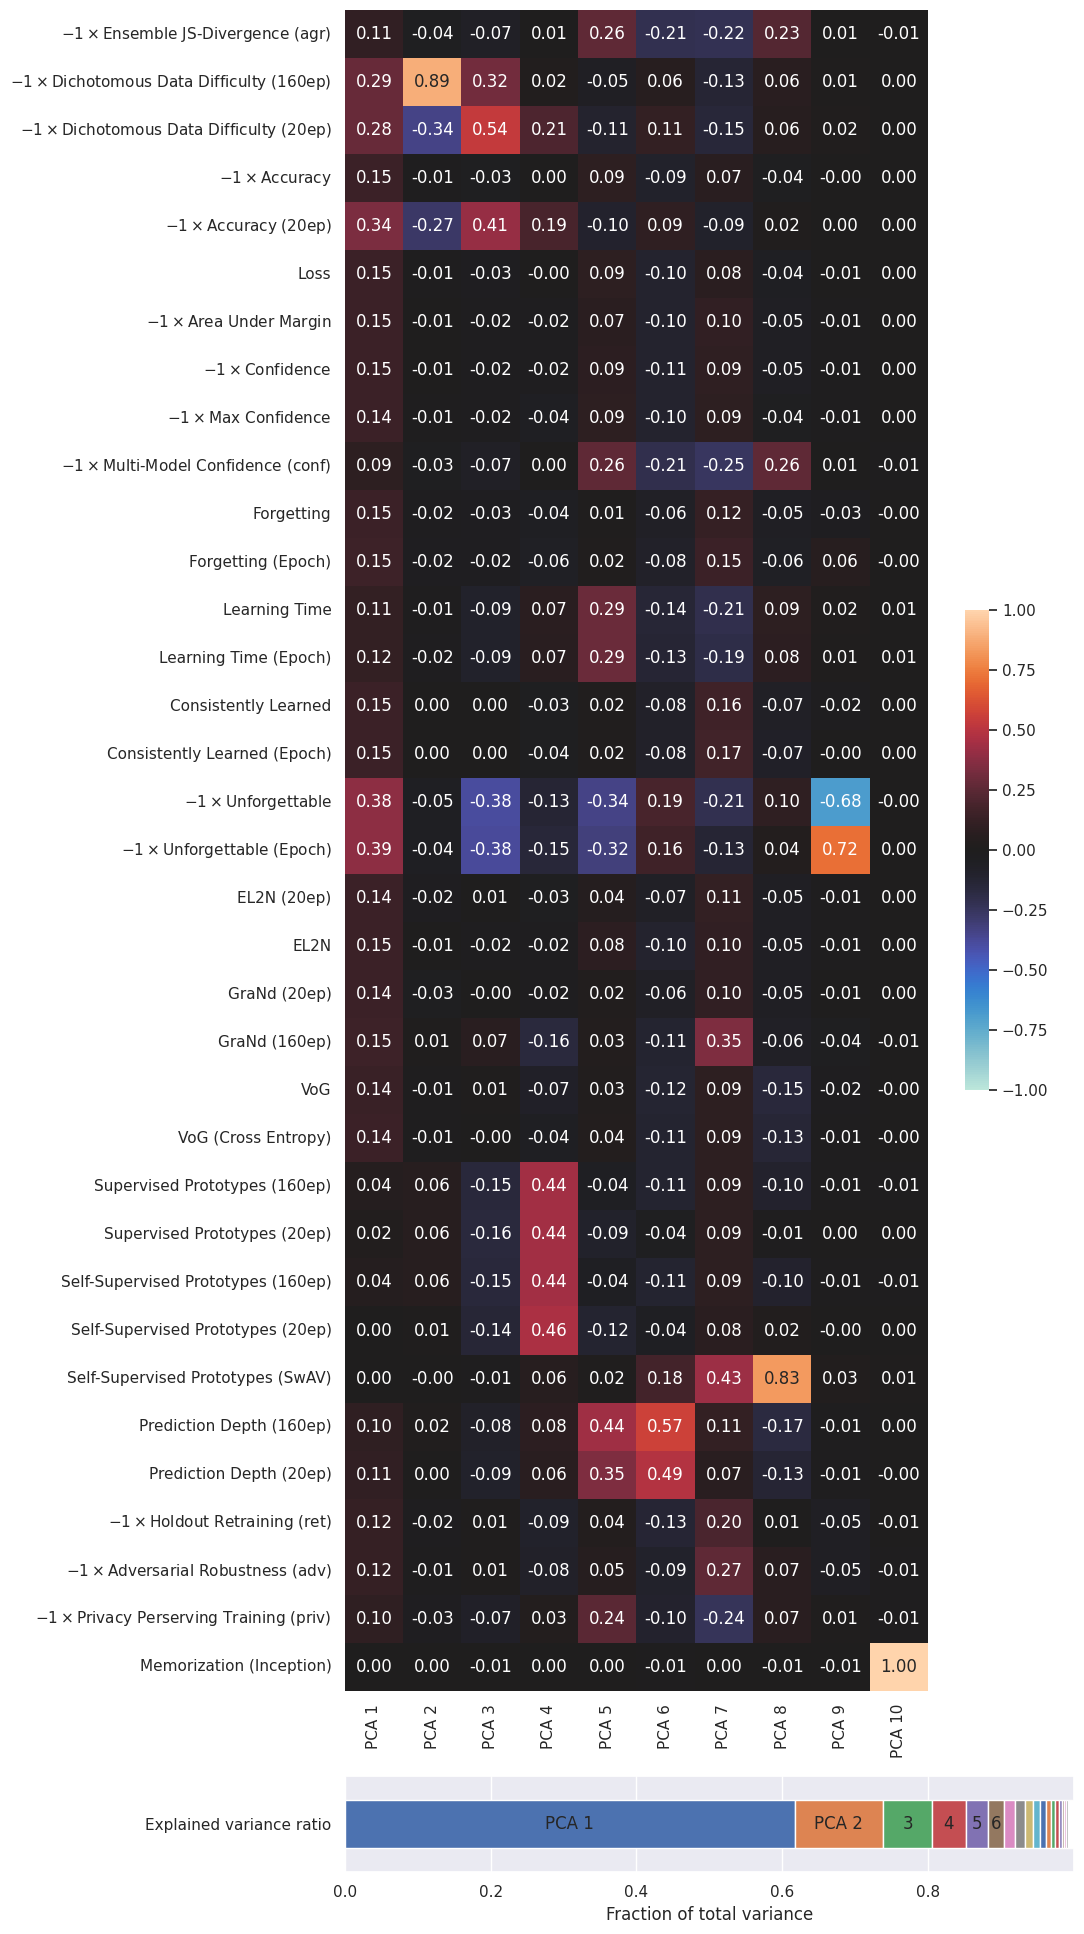

Saving figure to ../outputs/plots/pca/CIFAR-10-ResNet-20_std_pca.pdf


<Figure size 640x480 with 0 Axes>

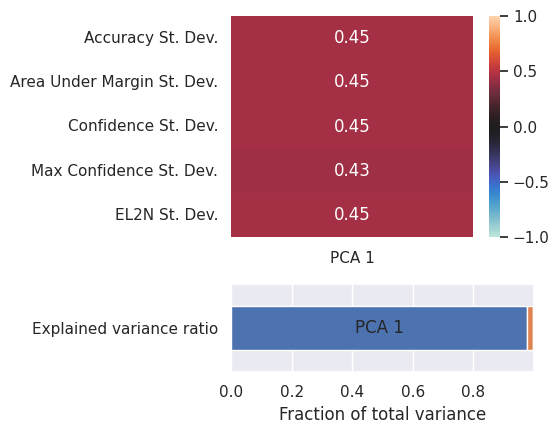

Saving figure to ../outputs/plots/pca/CIFAR-10-ResNet-20_runstd_pca.pdf


<Figure size 640x480 with 0 Axes>

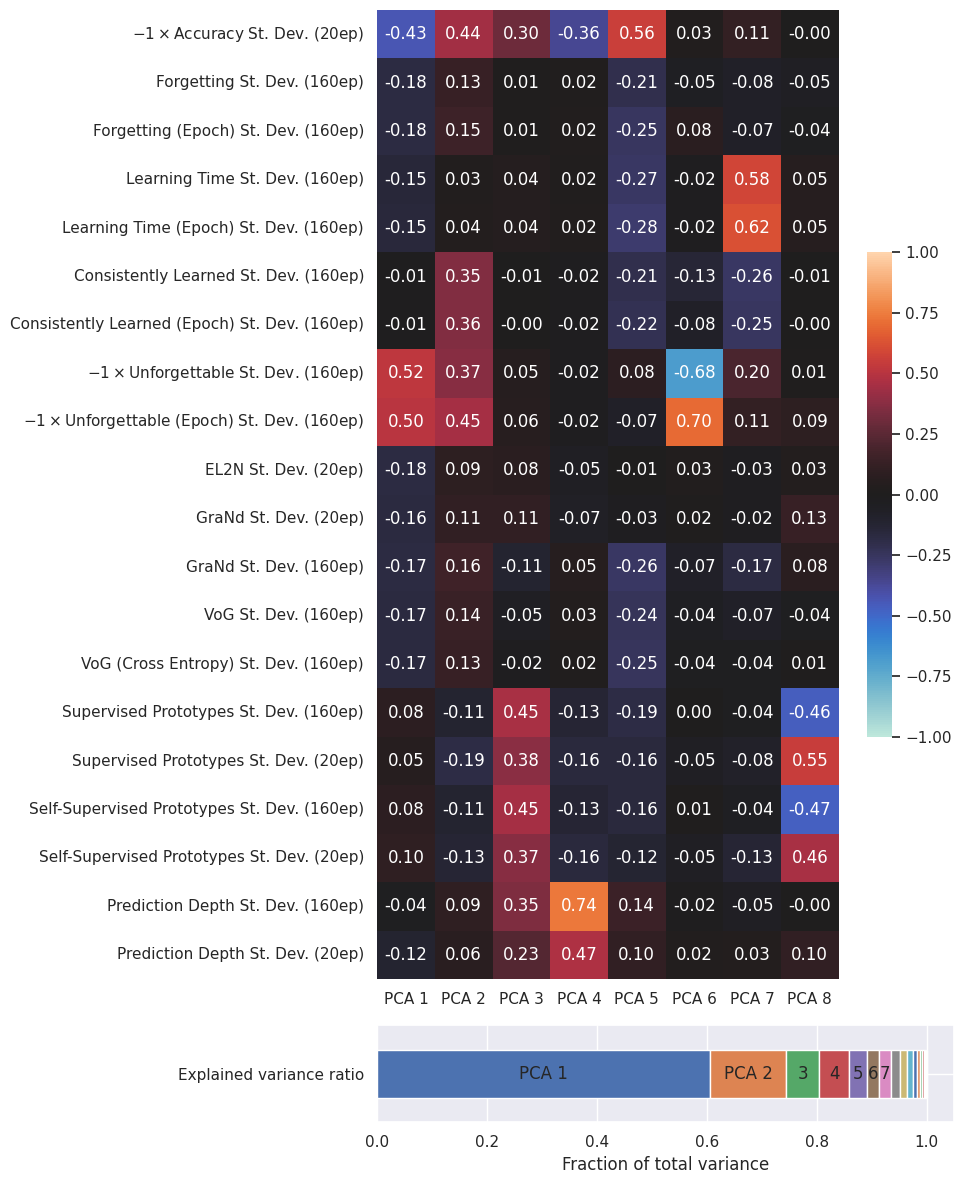

Columns: [Path, Replicate, Epoch, Method, Short Name, Full Name, Type, key, array, is_fuzzed, is_inverted]
Index: []
Saving figure to ../outputs/plots/pca/CIFAR-10-ResNet-20_all_plus_std_pca.pdf


<Figure size 640x480 with 0 Axes>

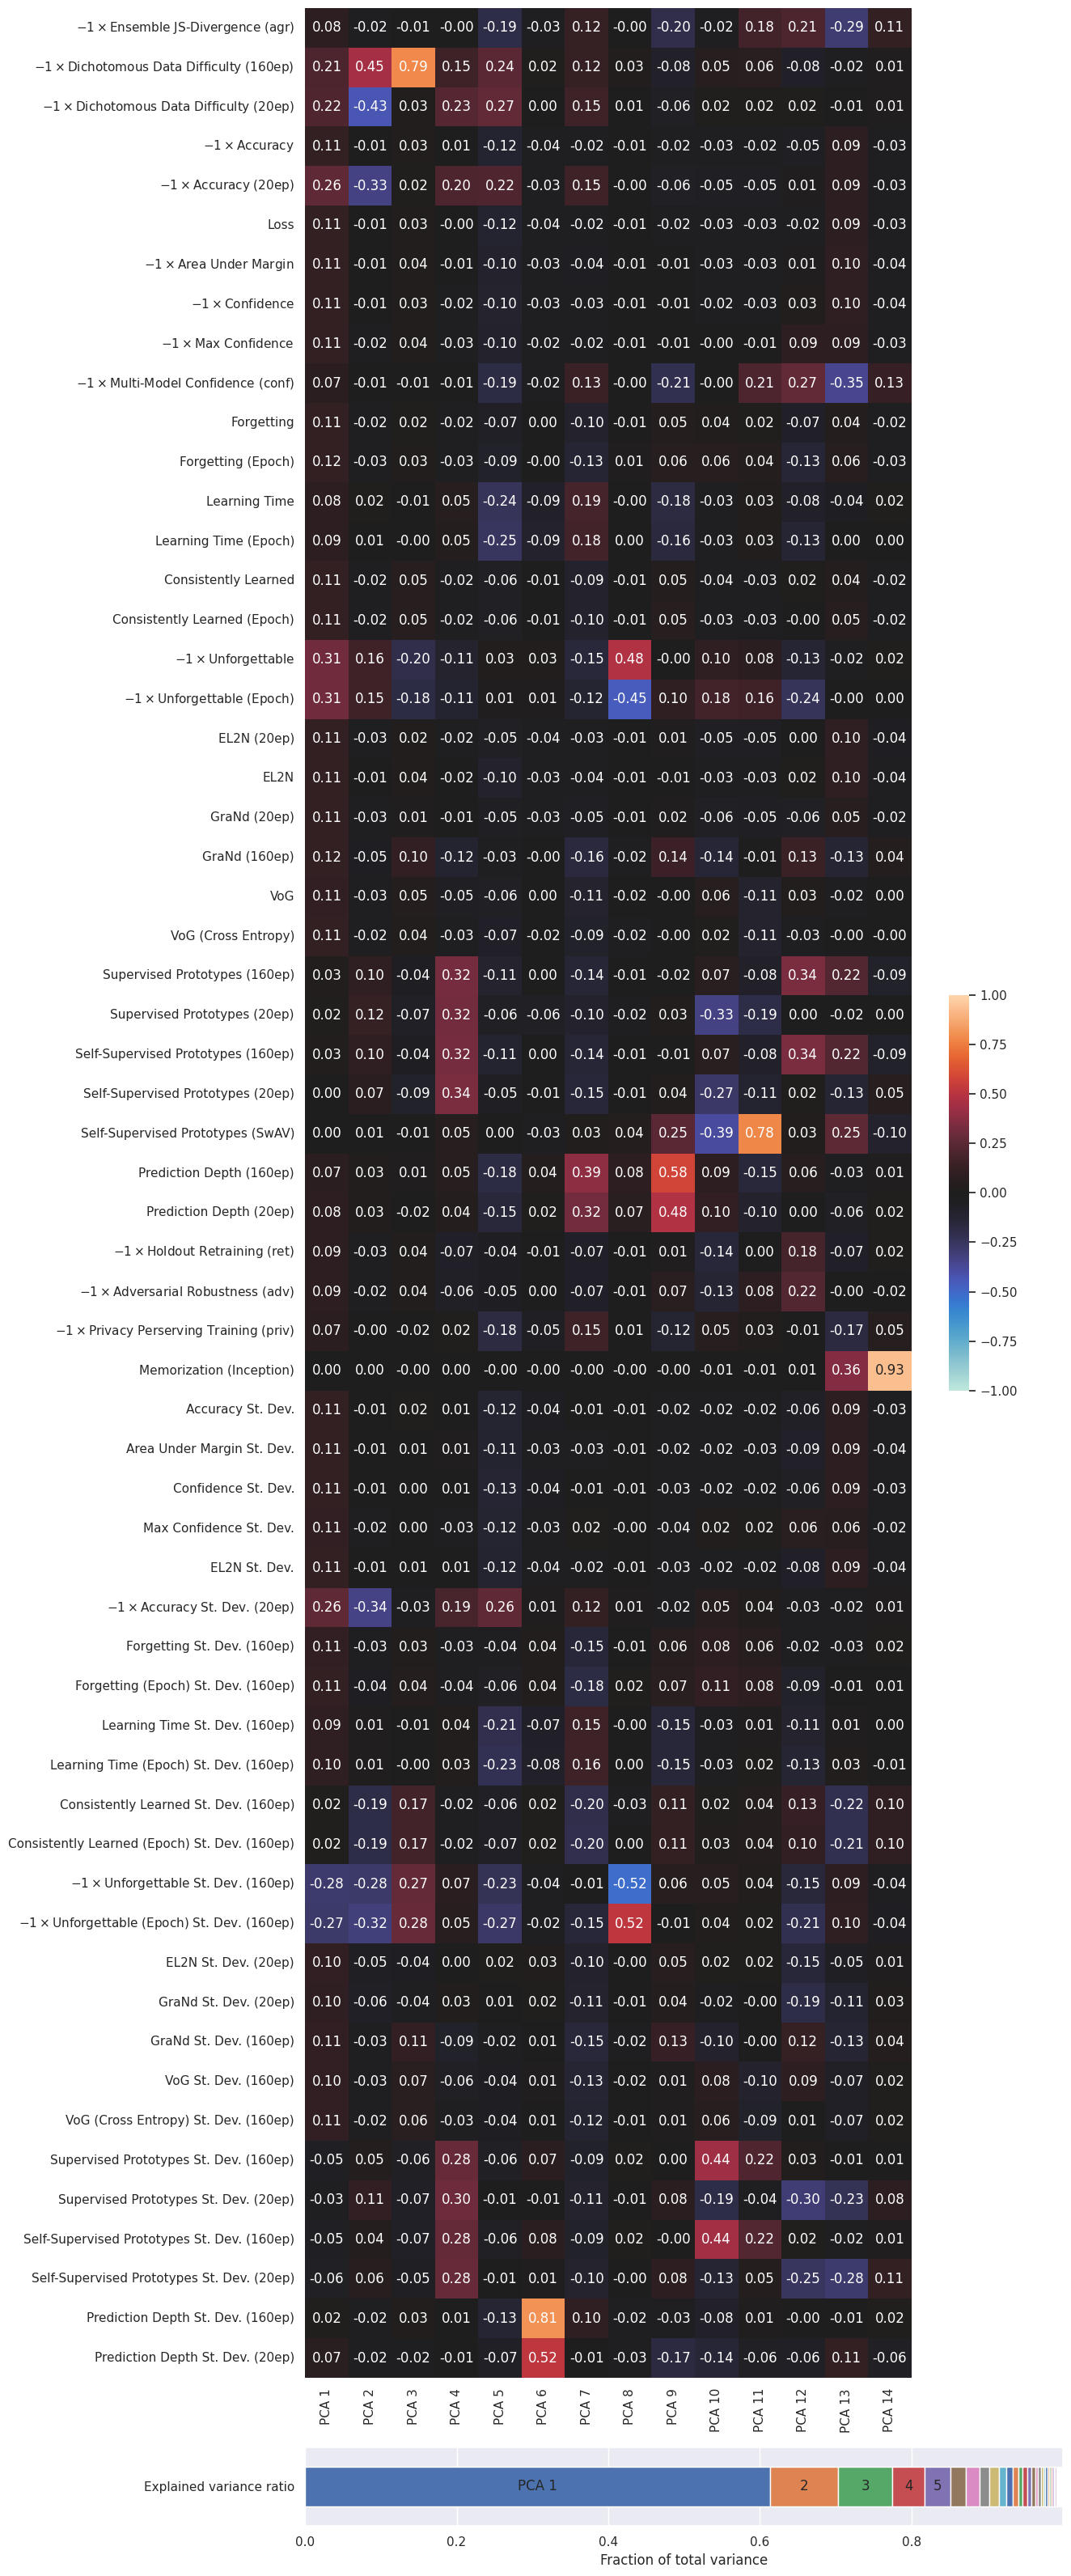

model_key                                            cifar_vgg_16
dataset_key                                               cifar10
Model                                                      VGG-16
Dataset                                                  CIFAR-10
Task                                              CIFAR-10/VGG-16
Parameters                                               14728266
path            ../outputs/combined/lottery_cf40a5a8bbe4f285b8...
key                      lottery_cf40a5a8bbe4f285b8fe317c1aa95dd5
n_replicates                                                  100
Name: 8, dtype: object
Unable to load memorization: Combination does not exist: , cifar10
Saving figure to ../outputs/plots/pca/CIFAR-10-VGG-16_selected_pca.pdf


<Figure size 640x480 with 0 Axes>

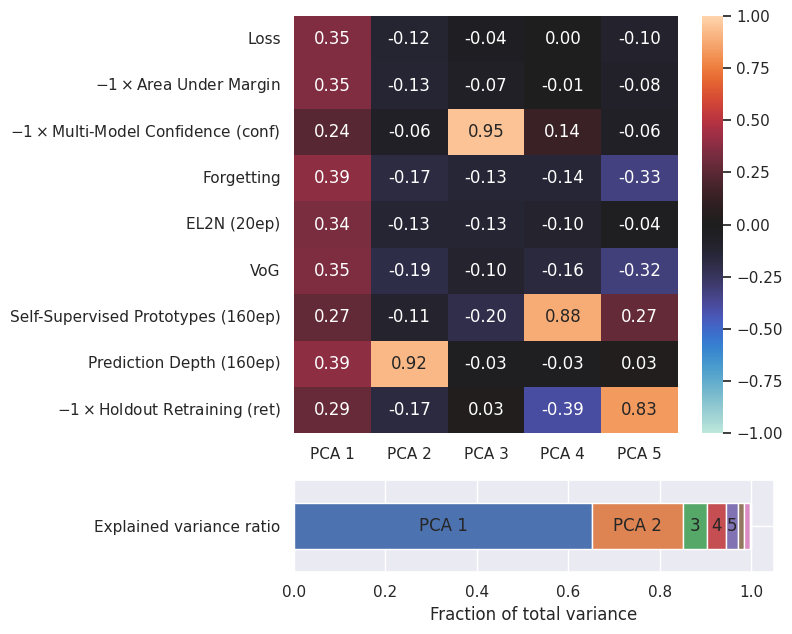

Saving figure to ../outputs/plots/pca/CIFAR-10-VGG-16_selected_plus_std_pca.pdf


<Figure size 640x480 with 0 Axes>

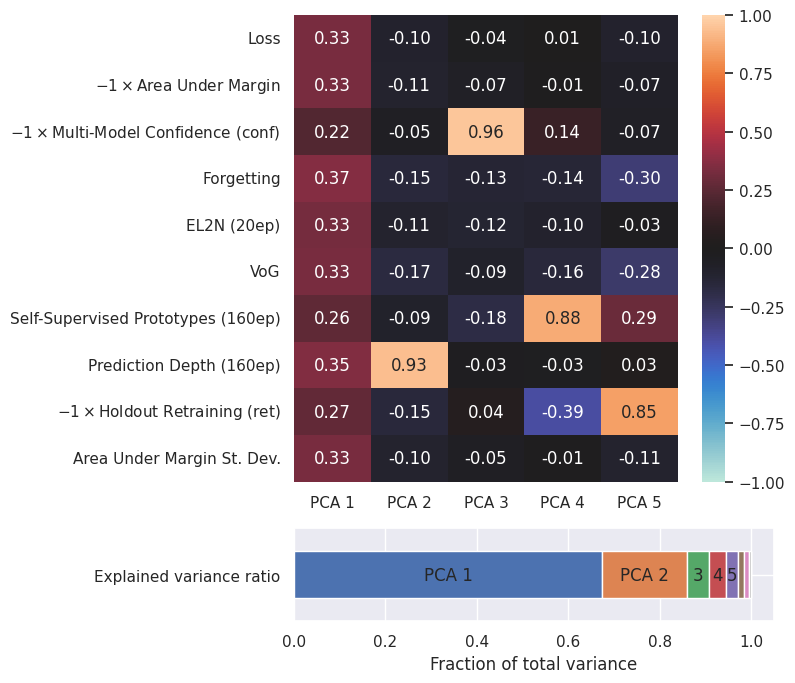

Saving figure to ../outputs/plots/pca/CIFAR-10-VGG-16_selected_plus_std_pca.pdf


<Figure size 640x480 with 0 Axes>

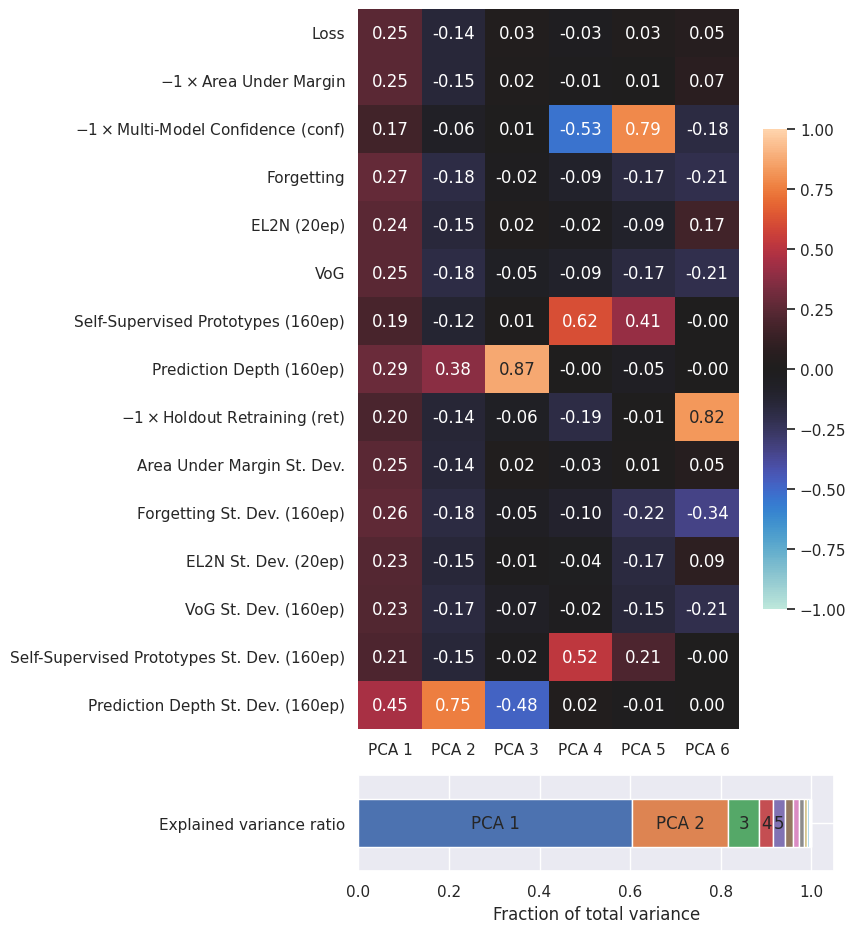

Columns: [Path, Replicate, Epoch, Method, Short Name, Full Name, Type, key, array, is_fuzzed, is_inverted]
Index: []
Saving figure to ../outputs/plots/pca/CIFAR-10-VGG-16_pca.pdf


<Figure size 640x480 with 0 Axes>

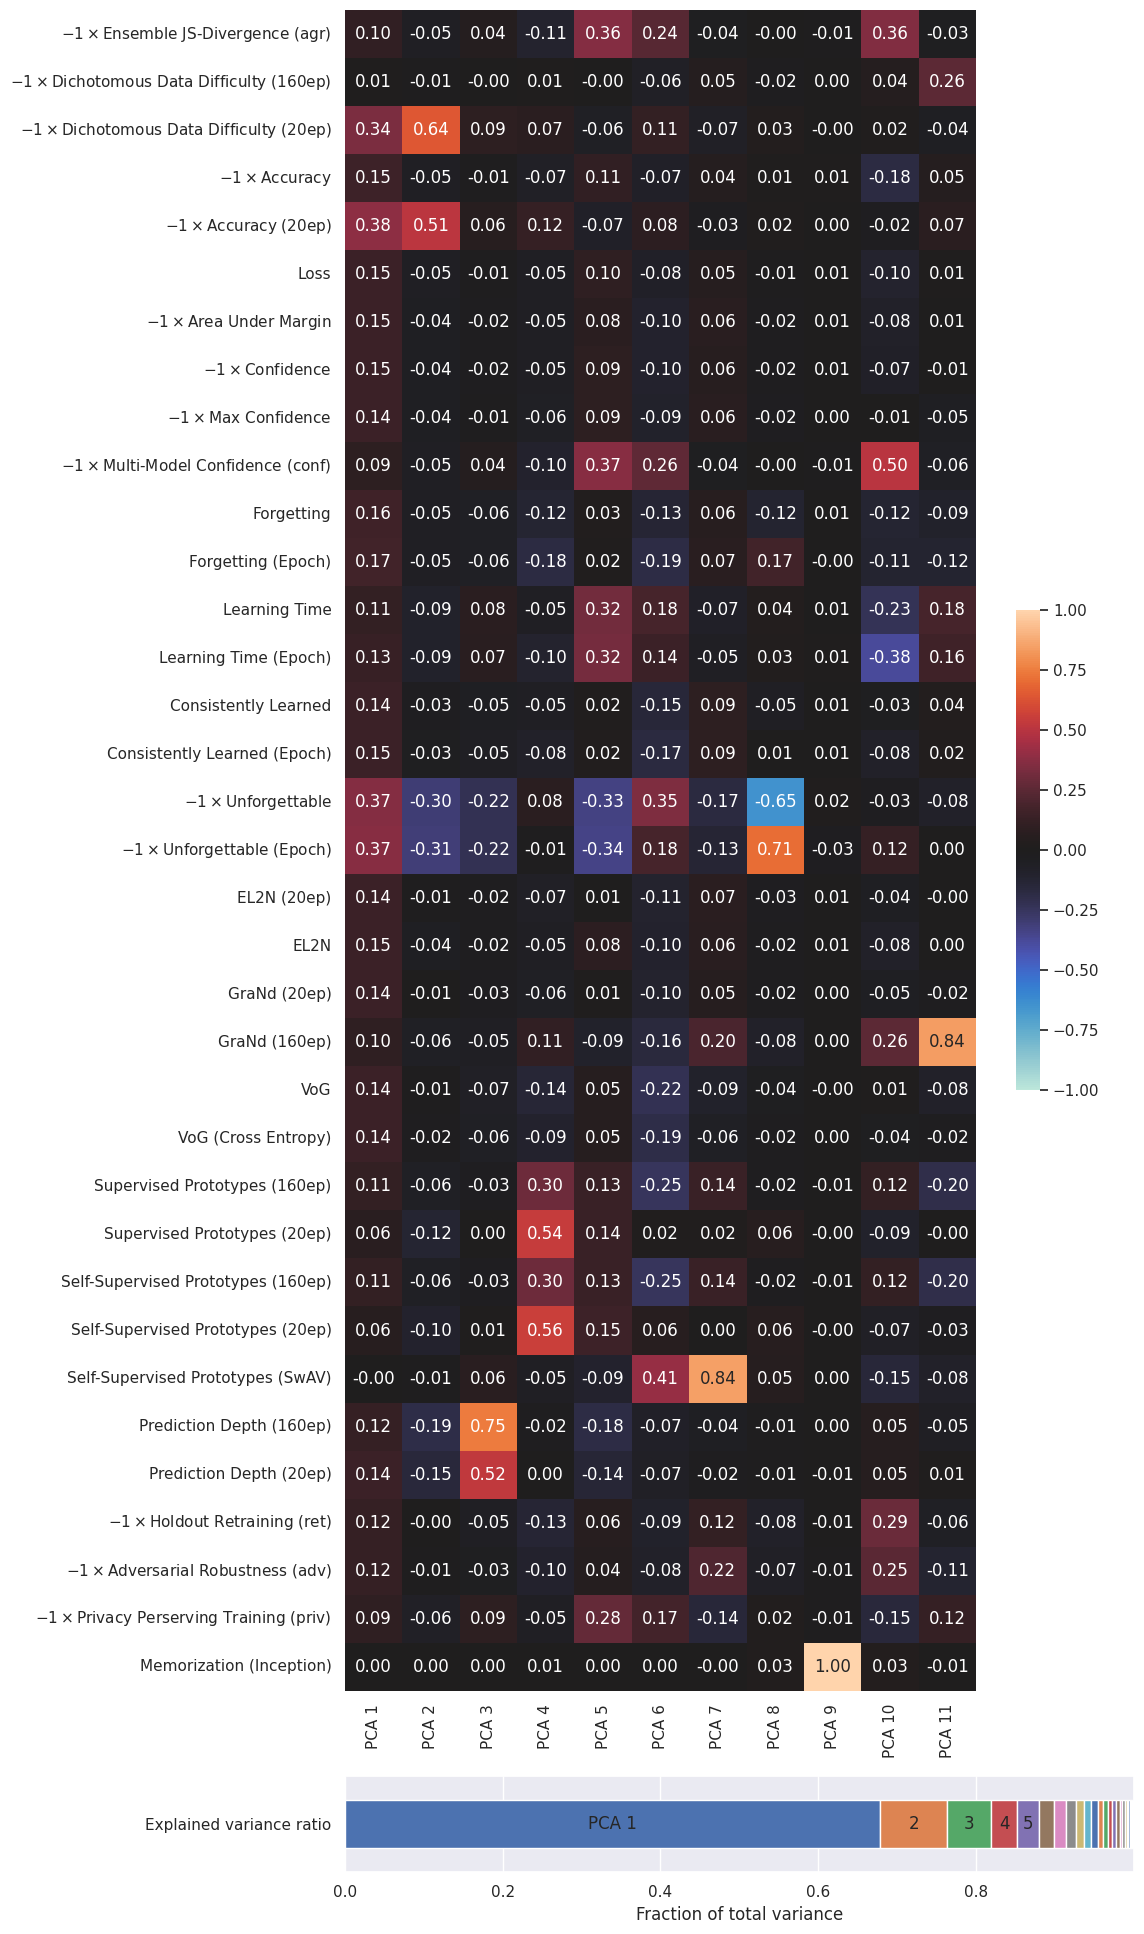

Saving figure to ../outputs/plots/pca/CIFAR-10-VGG-16_std_pca.pdf


<Figure size 640x480 with 0 Axes>

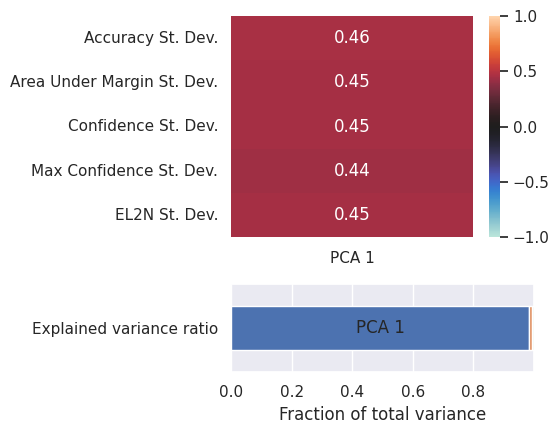

Saving figure to ../outputs/plots/pca/CIFAR-10-VGG-16_runstd_pca.pdf


<Figure size 640x480 with 0 Axes>

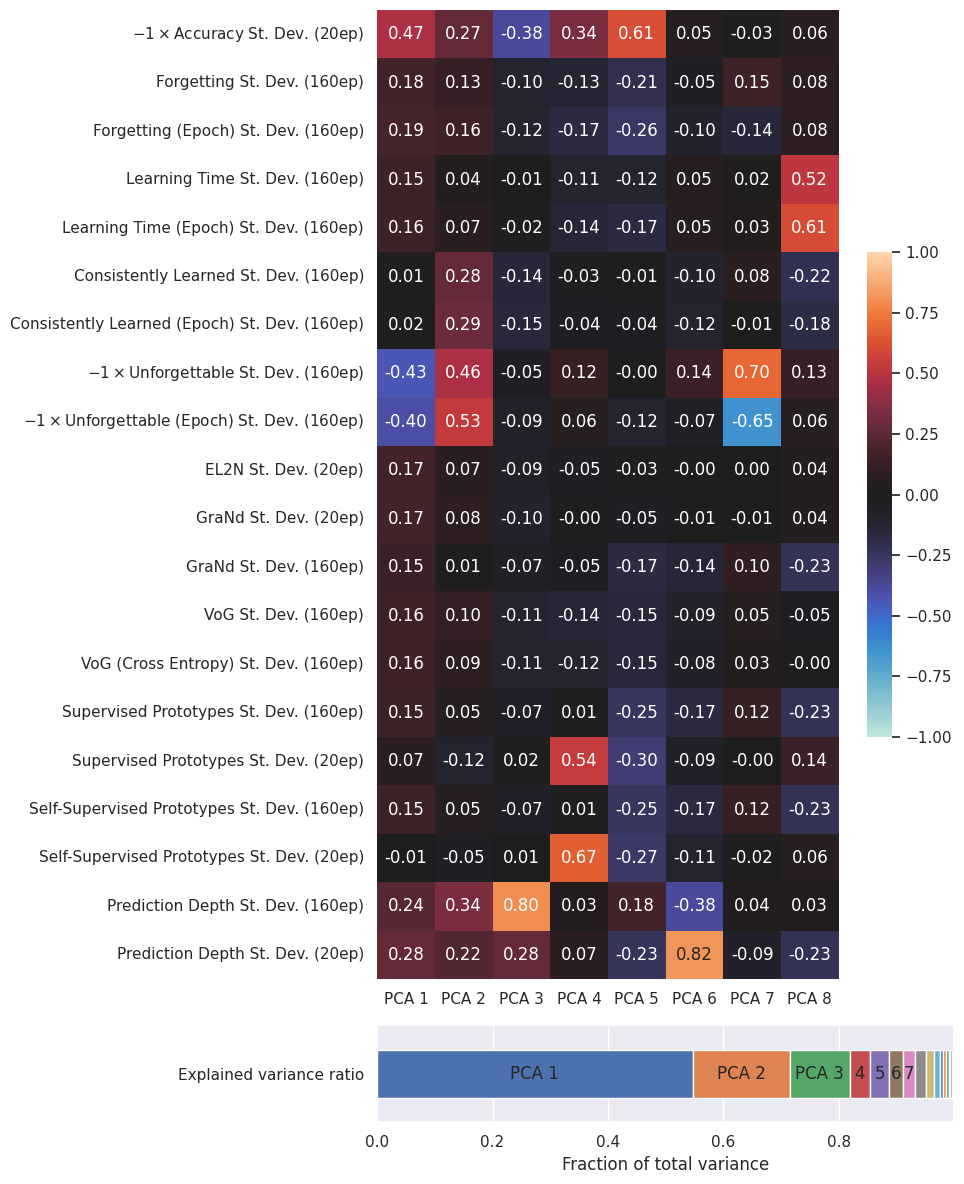

Columns: [Path, Replicate, Epoch, Method, Short Name, Full Name, Type, key, array, is_fuzzed, is_inverted]
Index: []
Saving figure to ../outputs/plots/pca/CIFAR-10-VGG-16_all_plus_std_pca.pdf


<Figure size 640x480 with 0 Axes>

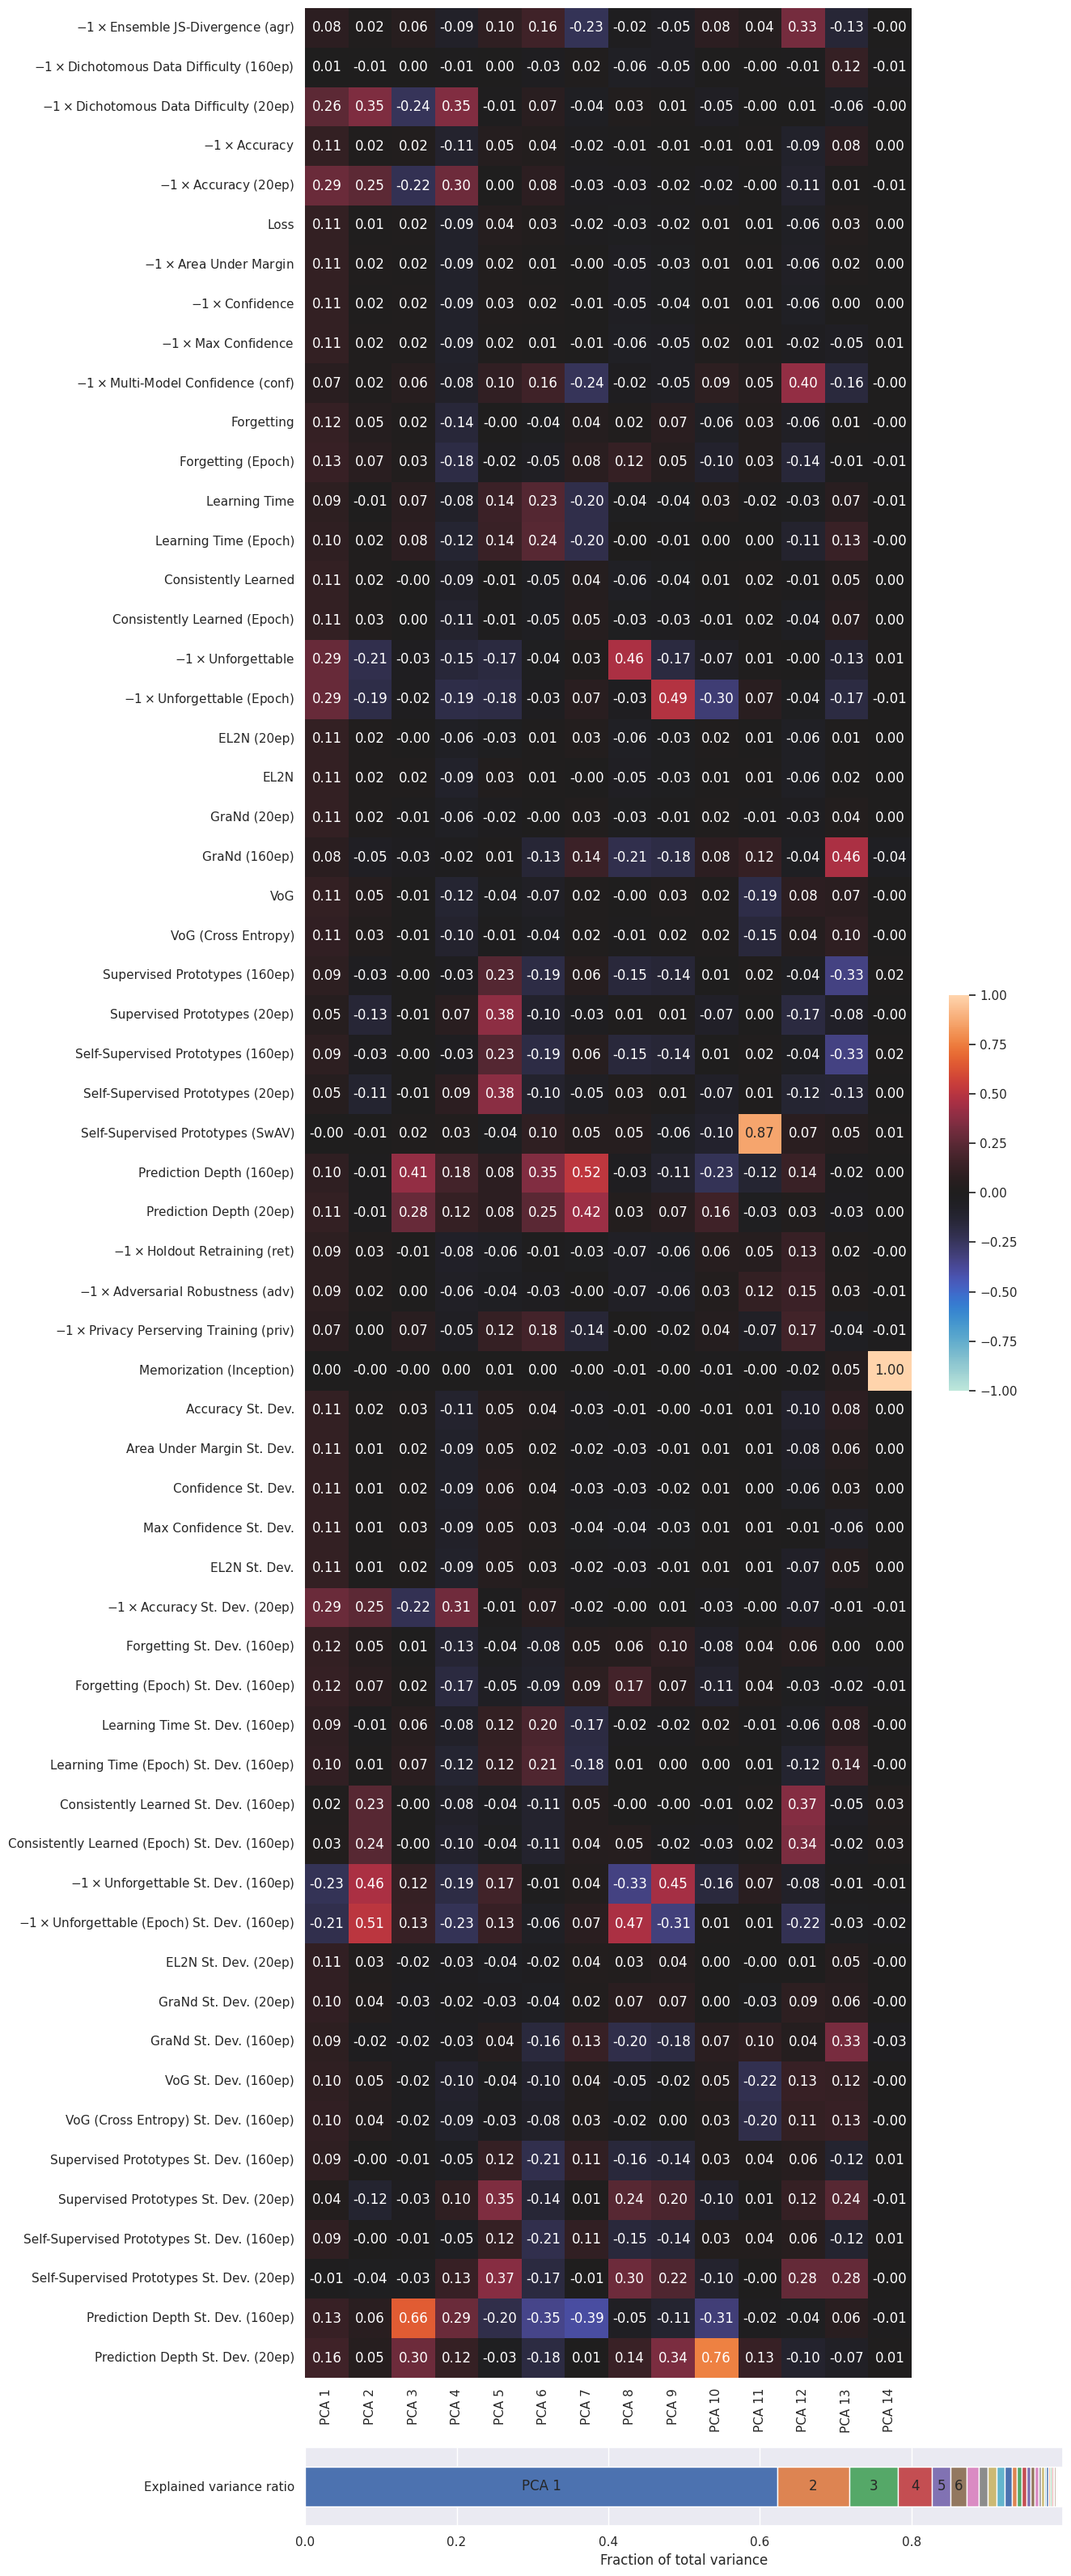

model_key                                            cifar_vgg_16
dataset_key                                              cifar100
Model                                                      VGG-16
Dataset                                                 CIFAR-100
Task                                             CIFAR-100/VGG-16
Parameters                                               14728266
path            ../outputs/combined/lottery_06562e05cda1bf840e...
key                      lottery_06562e05cda1bf840ee146490815ed82
n_replicates                                                  100
Name: 1, dtype: object
Grad and ckpt scores differ for ../outputs/combined/lottery_06562e05cda1bf840ee146490815ed82/replicate_100/level_0/main/gradmetrics/grand_20ep0it.npz: n=250, atol %=0.01470849338407377
Grad and ckpt scores differ for ../outputs/combined/lottery_06562e05cda1bf840ee146490815ed82/replicate_43/level_0/main/gradmetrics/grand_20ep0it.npz: n=270, atol %=0.01612396276328777
Grad and ckpt 

<Figure size 640x480 with 0 Axes>

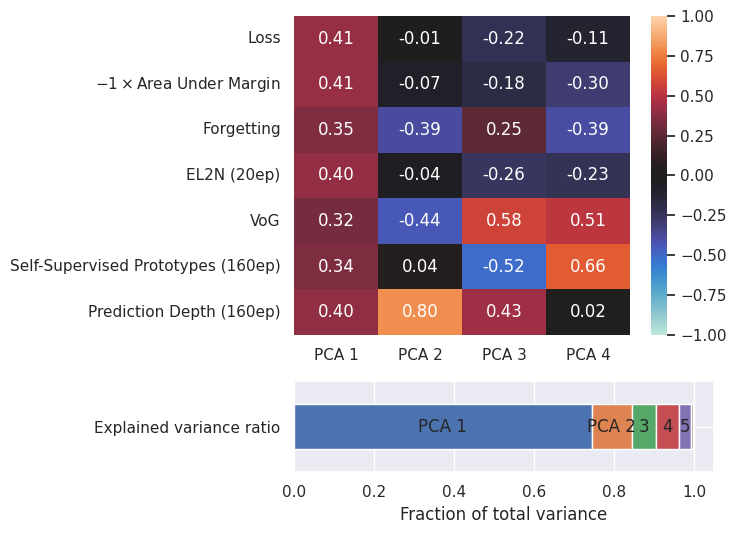

Columns: [Path, Replicate, Epoch, Method, Short Name, Full Name, Type, key, array, is_fuzzed, is_inverted]
Index: []
Columns: [Path, Replicate, Epoch, Method, Short Name, Full Name, Type, key, array, is_fuzzed, is_inverted]
Index: []
Saving figure to ../outputs/plots/pca/CIFAR-100-VGG-16_selected_plus_std_pca.pdf


<Figure size 640x480 with 0 Axes>

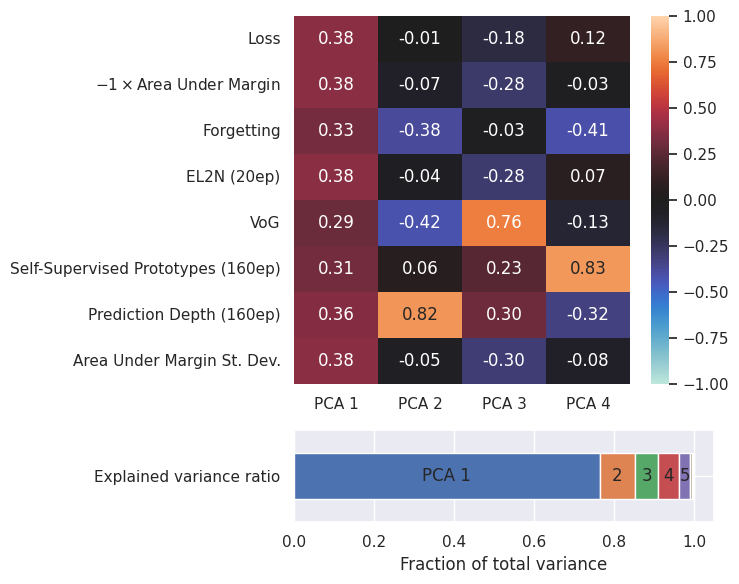

Columns: [Path, Replicate, Epoch, Method, Short Name, Full Name, Type, key, array, is_fuzzed, is_inverted]
Index: []
Columns: [Path, Replicate, Epoch, Method, Short Name, Full Name, Type, key, array, is_fuzzed, is_inverted]
Index: []
Saving figure to ../outputs/plots/pca/CIFAR-100-VGG-16_selected_plus_std_pca.pdf


<Figure size 640x480 with 0 Axes>

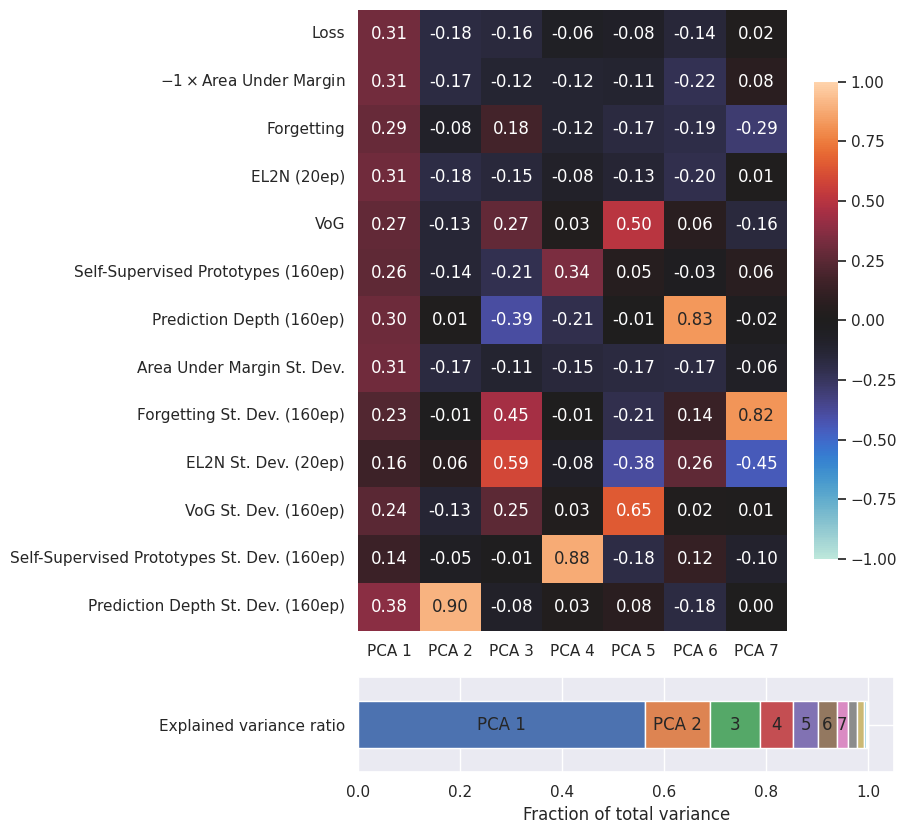

Columns: [Path, Replicate, Epoch, Method, Short Name, Full Name, Type, key, array, is_fuzzed, is_inverted]
Index: []
Columns: [Path, Replicate, Epoch, Method, Short Name, Full Name, Type, key, array, is_fuzzed, is_inverted]
Index: []
Columns: [Path, Replicate, Epoch, Method, Short Name, Full Name, Type, key, array, is_fuzzed, is_inverted]
Index: []
Columns: [Path, Replicate, Epoch, Method, Short Name, Full Name, Type, key, array, is_fuzzed, is_inverted]
Index: []
Columns: [Path, Replicate, Epoch, Method, Short Name, Full Name, Type, key, array, is_fuzzed, is_inverted]
Index: []
Columns: [Path, Replicate, Epoch, Method, Short Name, Full Name, Type, key, array, is_fuzzed, is_inverted]
Index: []
Saving figure to ../outputs/plots/pca/CIFAR-100-VGG-16_pca.pdf


<Figure size 640x480 with 0 Axes>

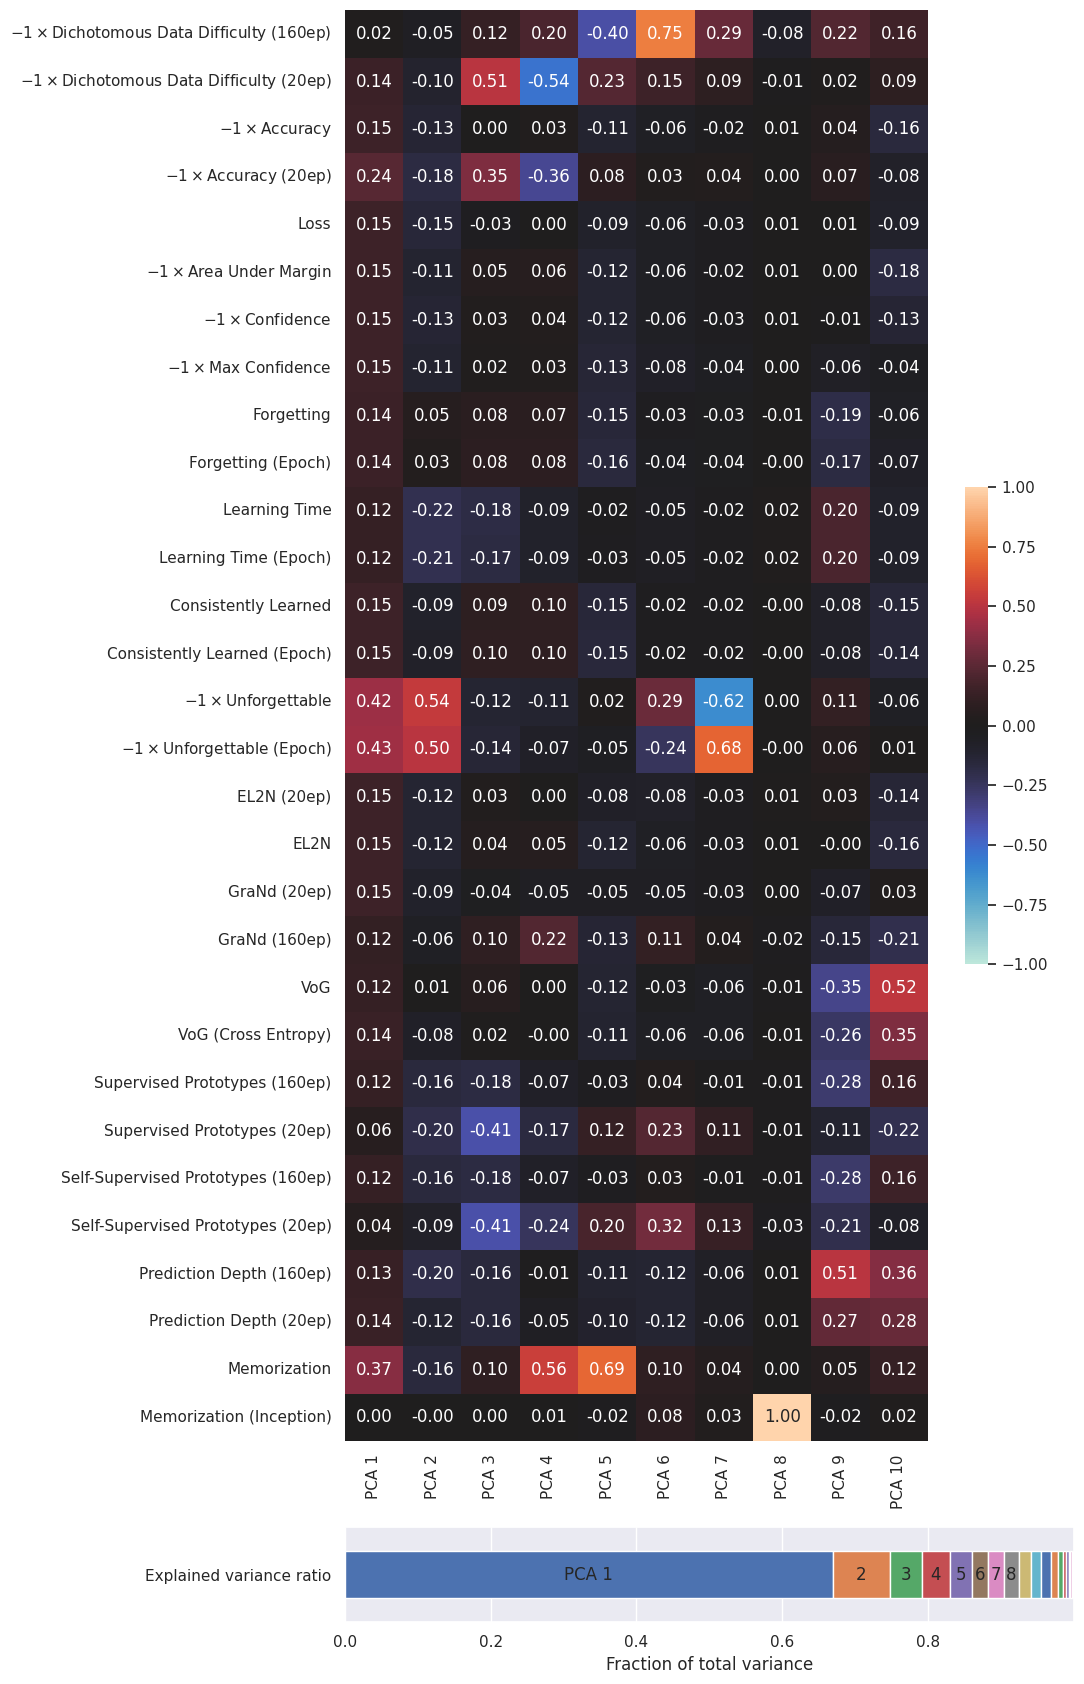

Saving figure to ../outputs/plots/pca/CIFAR-100-VGG-16_std_pca.pdf


<Figure size 640x480 with 0 Axes>

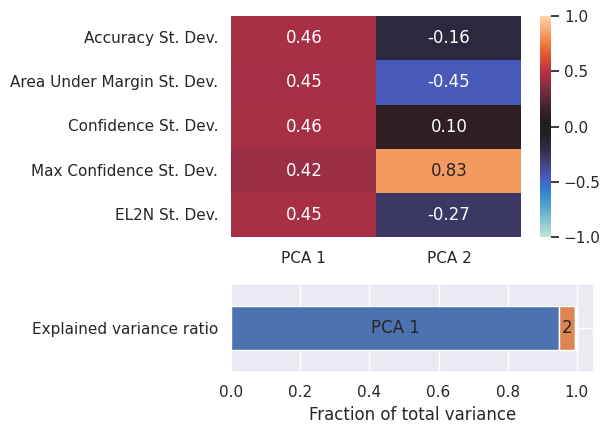

Saving figure to ../outputs/plots/pca/CIFAR-100-VGG-16_runstd_pca.pdf


<Figure size 640x480 with 0 Axes>

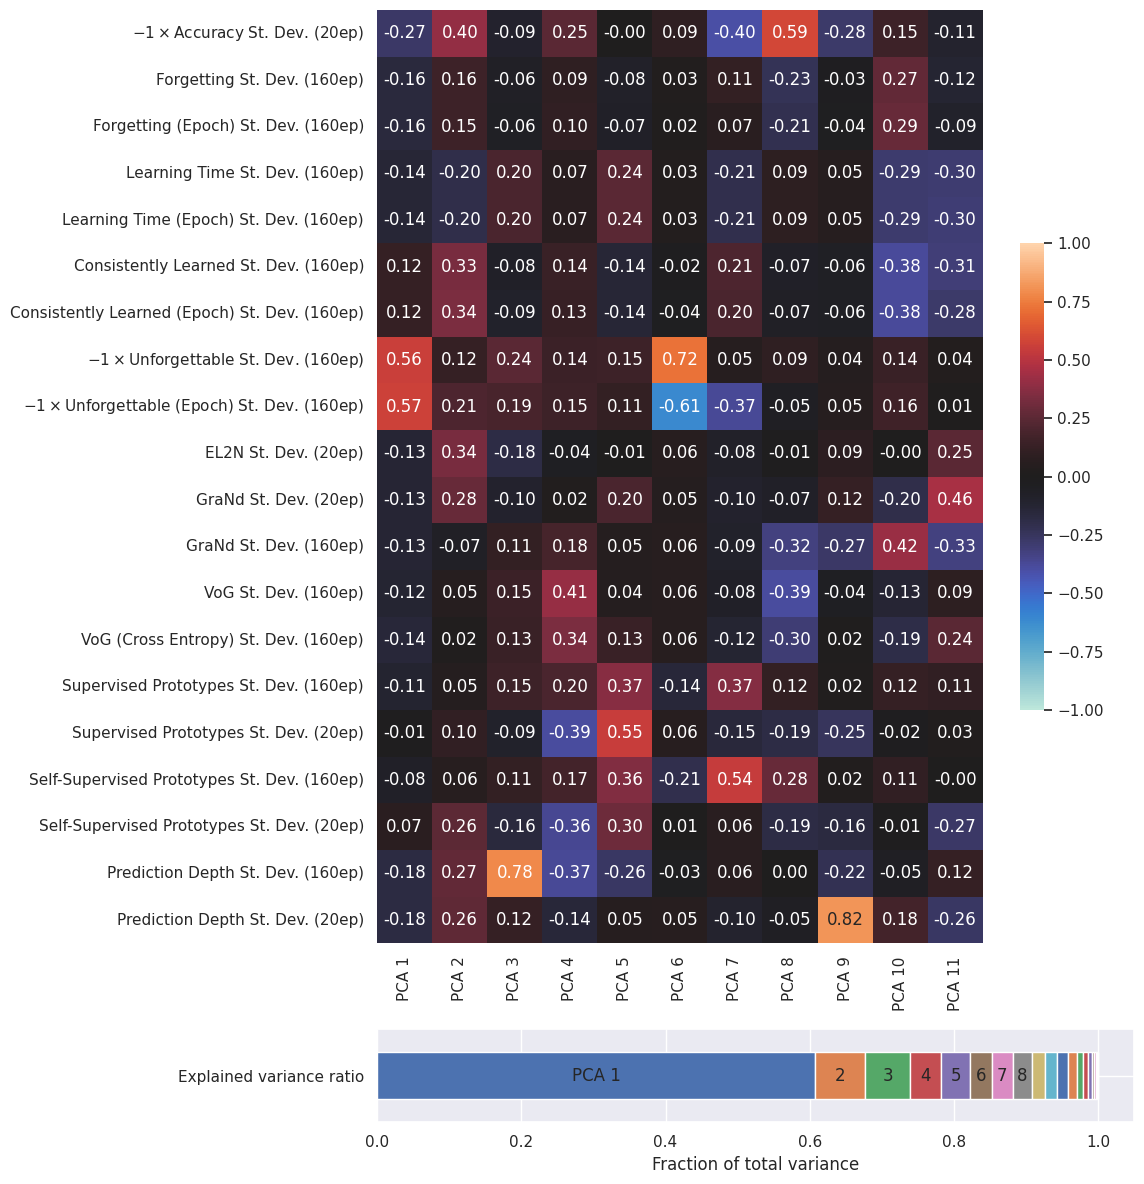

Columns: [Path, Replicate, Epoch, Method, Short Name, Full Name, Type, key, array, is_fuzzed, is_inverted]
Index: []
Columns: [Path, Replicate, Epoch, Method, Short Name, Full Name, Type, key, array, is_fuzzed, is_inverted]
Index: []
Columns: [Path, Replicate, Epoch, Method, Short Name, Full Name, Type, key, array, is_fuzzed, is_inverted]
Index: []
Columns: [Path, Replicate, Epoch, Method, Short Name, Full Name, Type, key, array, is_fuzzed, is_inverted]
Index: []
Columns: [Path, Replicate, Epoch, Method, Short Name, Full Name, Type, key, array, is_fuzzed, is_inverted]
Index: []
Columns: [Path, Replicate, Epoch, Method, Short Name, Full Name, Type, key, array, is_fuzzed, is_inverted]
Index: []
Saving figure to ../outputs/plots/pca/CIFAR-100-VGG-16_all_plus_std_pca.pdf


<Figure size 640x480 with 0 Axes>

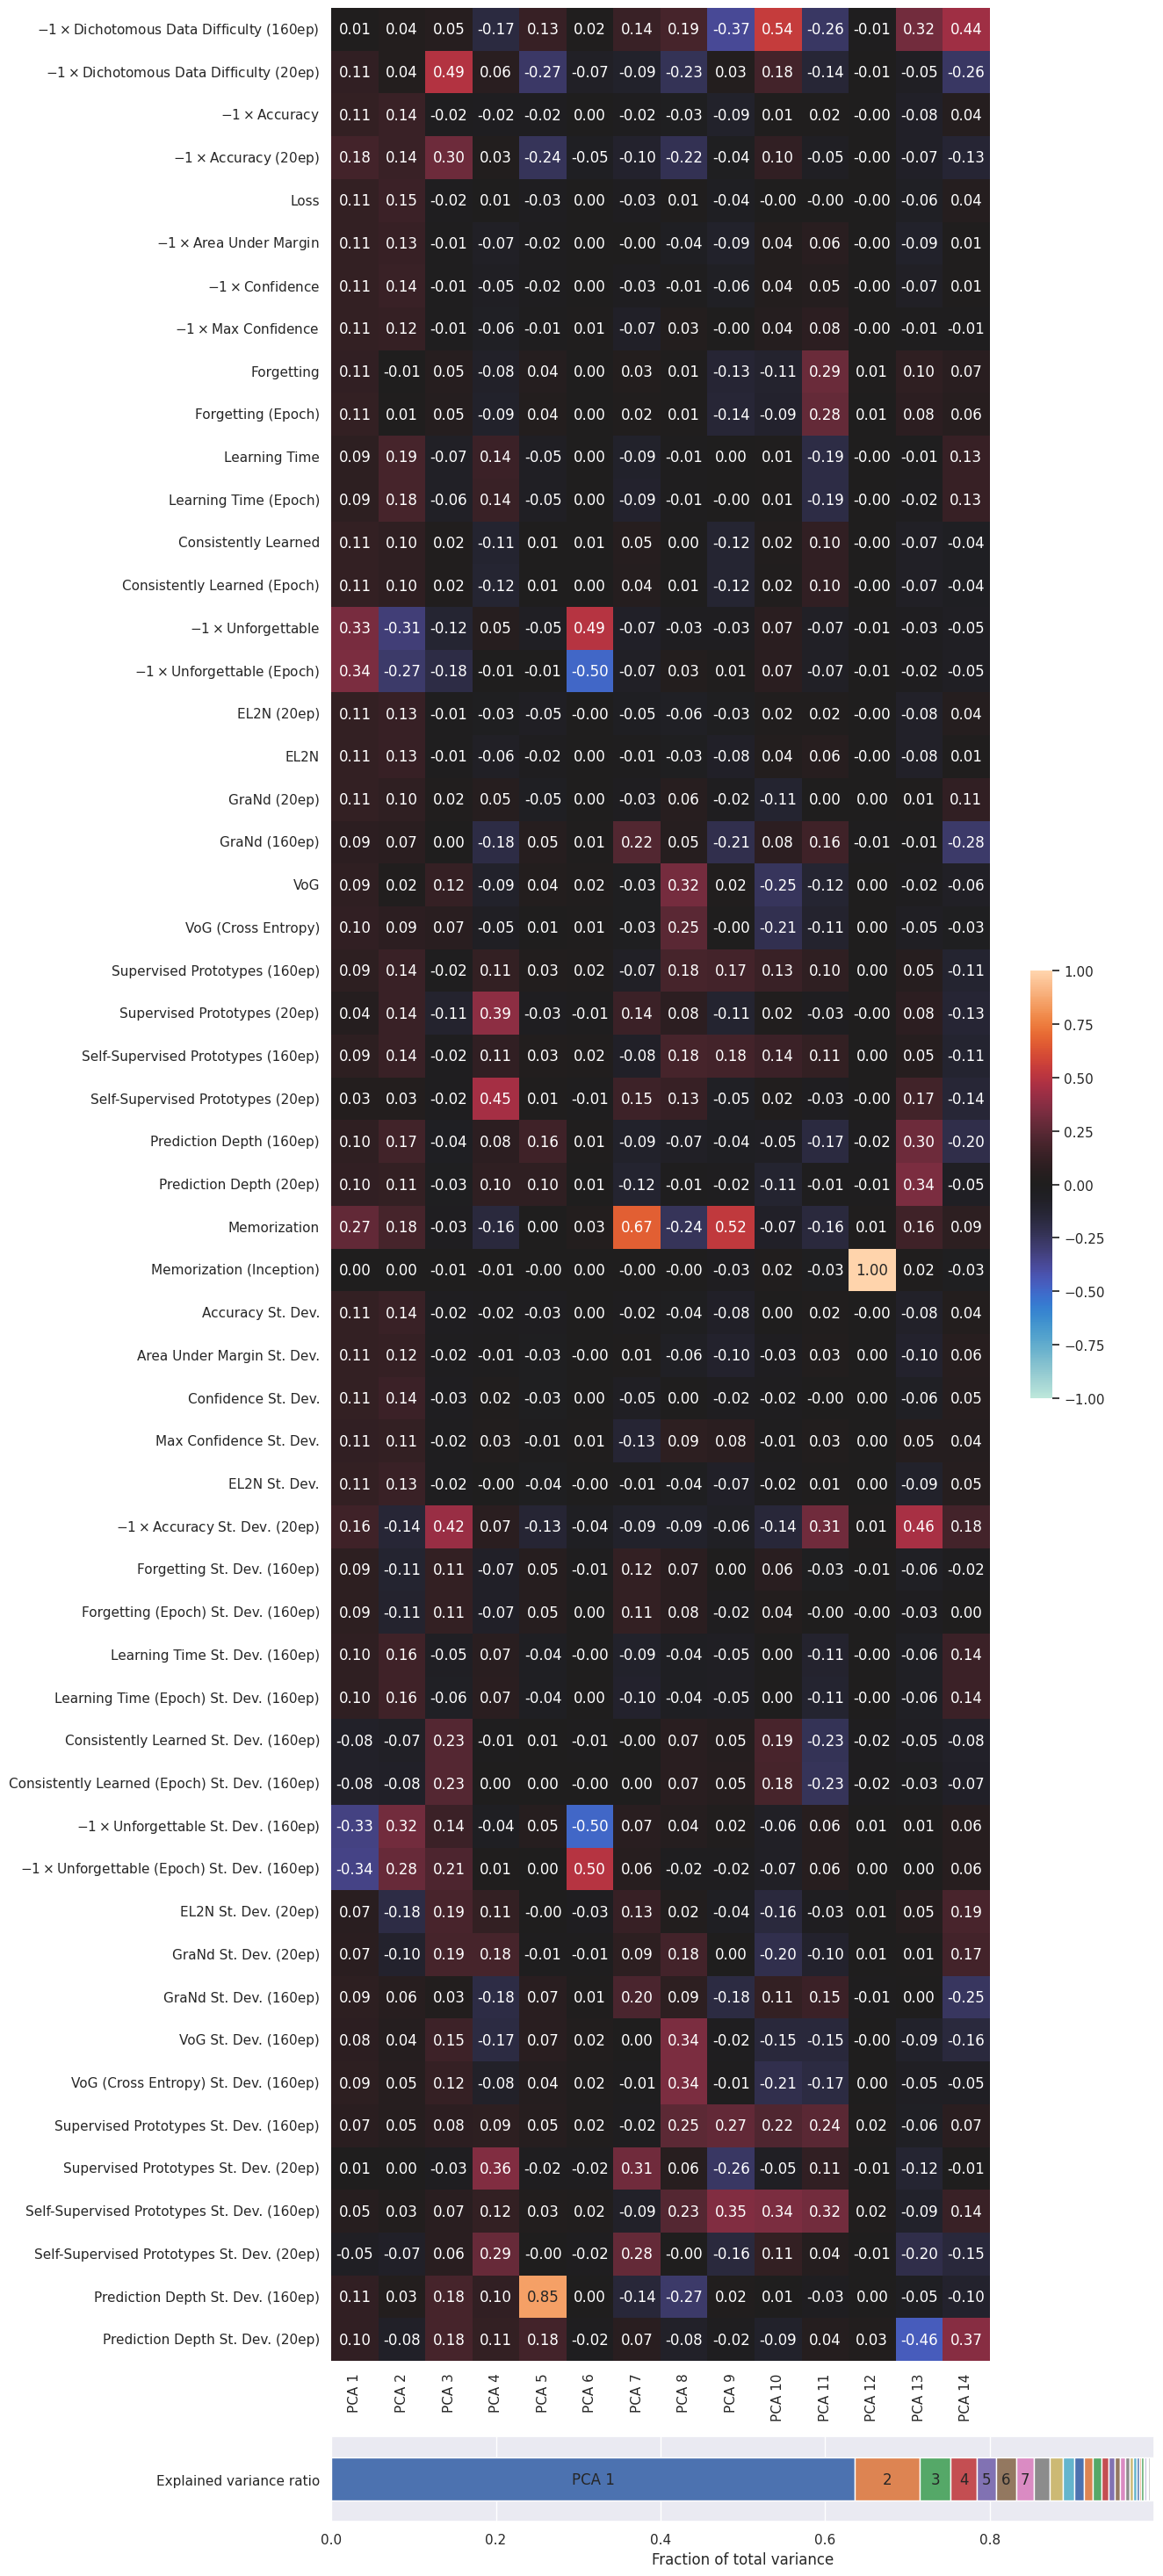

model_key                                         cifar_resnet_20
dataset_key                                              cifar100
Model                                                   ResNet-20
Dataset                                                 CIFAR-100
Task                                          CIFAR-100/ResNet-20
Parameters                                                 272474
path            ../outputs/combined/lottery_9dc2b8dfff54c4da57...
key                      lottery_9dc2b8dfff54c4da57570d7b391dcccd
n_replicates                                                  100
Name: 6, dtype: object
Grad and ckpt scores differ for ../outputs/combined/lottery_9dc2b8dfff54c4da57570d7b391dcccd/replicate_54/level_0/main/gradmetrics/grand_20ep0it.npz: n=61, atol %=0.011354232836572874
Grad and ckpt scores differ for ../outputs/combined/lottery_9dc2b8dfff54c4da57570d7b391dcccd/replicate_56/level_0/main/gradmetrics/grand_20ep0it.npz: n=50, atol %=0.01291863552310424
Grad and ckpt sc

<Figure size 640x480 with 0 Axes>

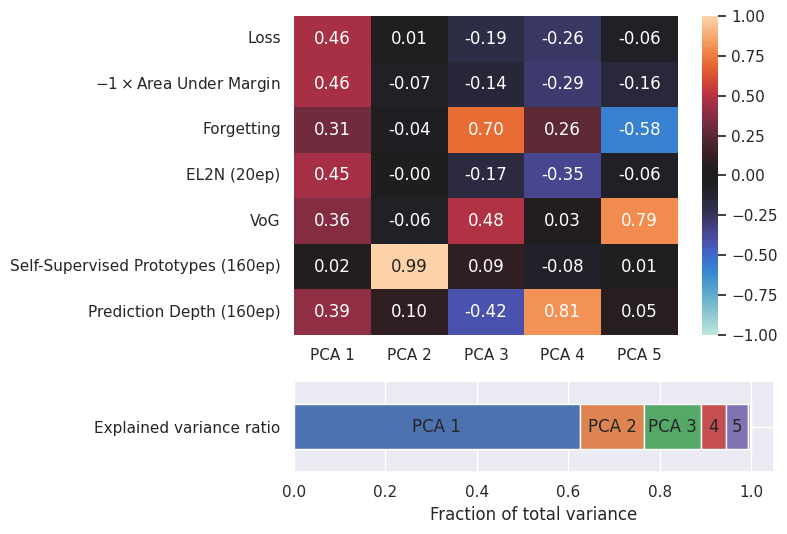

Columns: [Path, Replicate, Epoch, Method, Short Name, Full Name, Type, key, array, is_fuzzed, is_inverted]
Index: []
Columns: [Path, Replicate, Epoch, Method, Short Name, Full Name, Type, key, array, is_fuzzed, is_inverted]
Index: []
Saving figure to ../outputs/plots/pca/CIFAR-100-ResNet-20_selected_plus_std_pca.pdf


<Figure size 640x480 with 0 Axes>

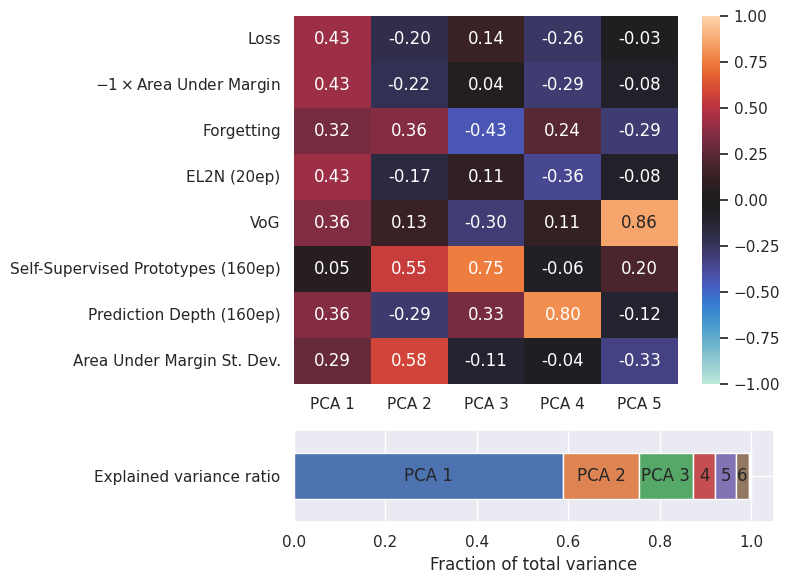

Columns: [Path, Replicate, Epoch, Method, Short Name, Full Name, Type, key, array, is_fuzzed, is_inverted]
Index: []
Columns: [Path, Replicate, Epoch, Method, Short Name, Full Name, Type, key, array, is_fuzzed, is_inverted]
Index: []
Saving figure to ../outputs/plots/pca/CIFAR-100-ResNet-20_selected_plus_std_pca.pdf


<Figure size 640x480 with 0 Axes>

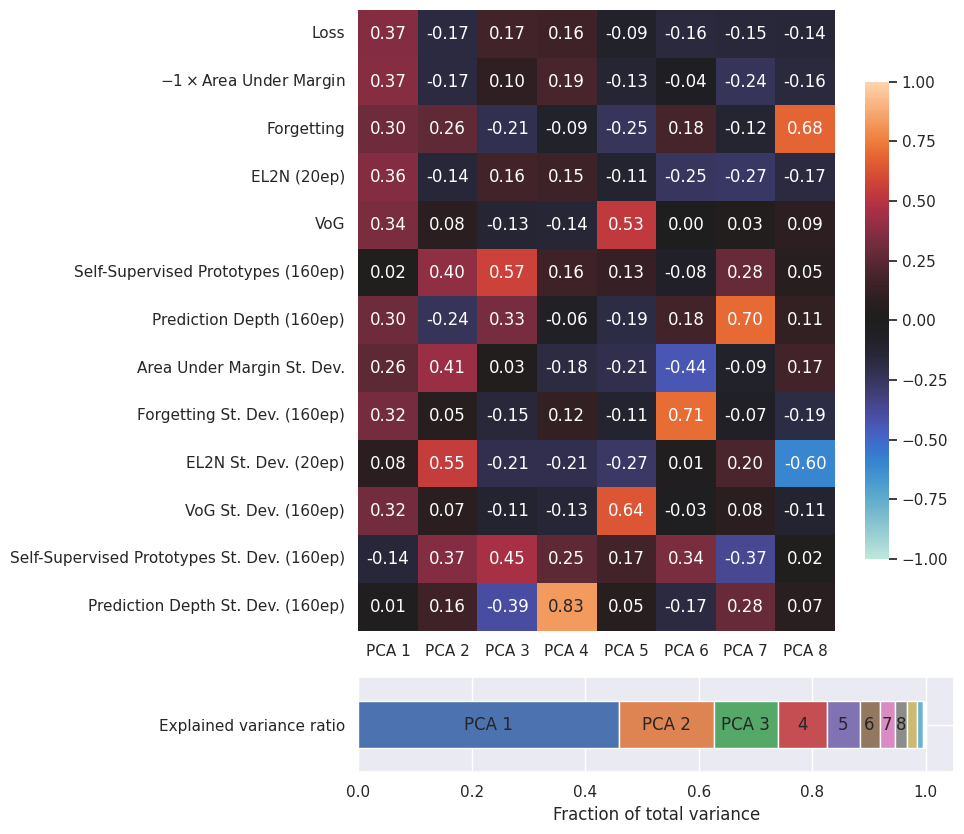

Columns: [Path, Replicate, Epoch, Method, Short Name, Full Name, Type, key, array, is_fuzzed, is_inverted]
Index: []
Columns: [Path, Replicate, Epoch, Method, Short Name, Full Name, Type, key, array, is_fuzzed, is_inverted]
Index: []
Columns: [Path, Replicate, Epoch, Method, Short Name, Full Name, Type, key, array, is_fuzzed, is_inverted]
Index: []
Columns: [Path, Replicate, Epoch, Method, Short Name, Full Name, Type, key, array, is_fuzzed, is_inverted]
Index: []
Columns: [Path, Replicate, Epoch, Method, Short Name, Full Name, Type, key, array, is_fuzzed, is_inverted]
Index: []
Columns: [Path, Replicate, Epoch, Method, Short Name, Full Name, Type, key, array, is_fuzzed, is_inverted]
Index: []
Saving figure to ../outputs/plots/pca/CIFAR-100-ResNet-20_pca.pdf


<Figure size 640x480 with 0 Axes>

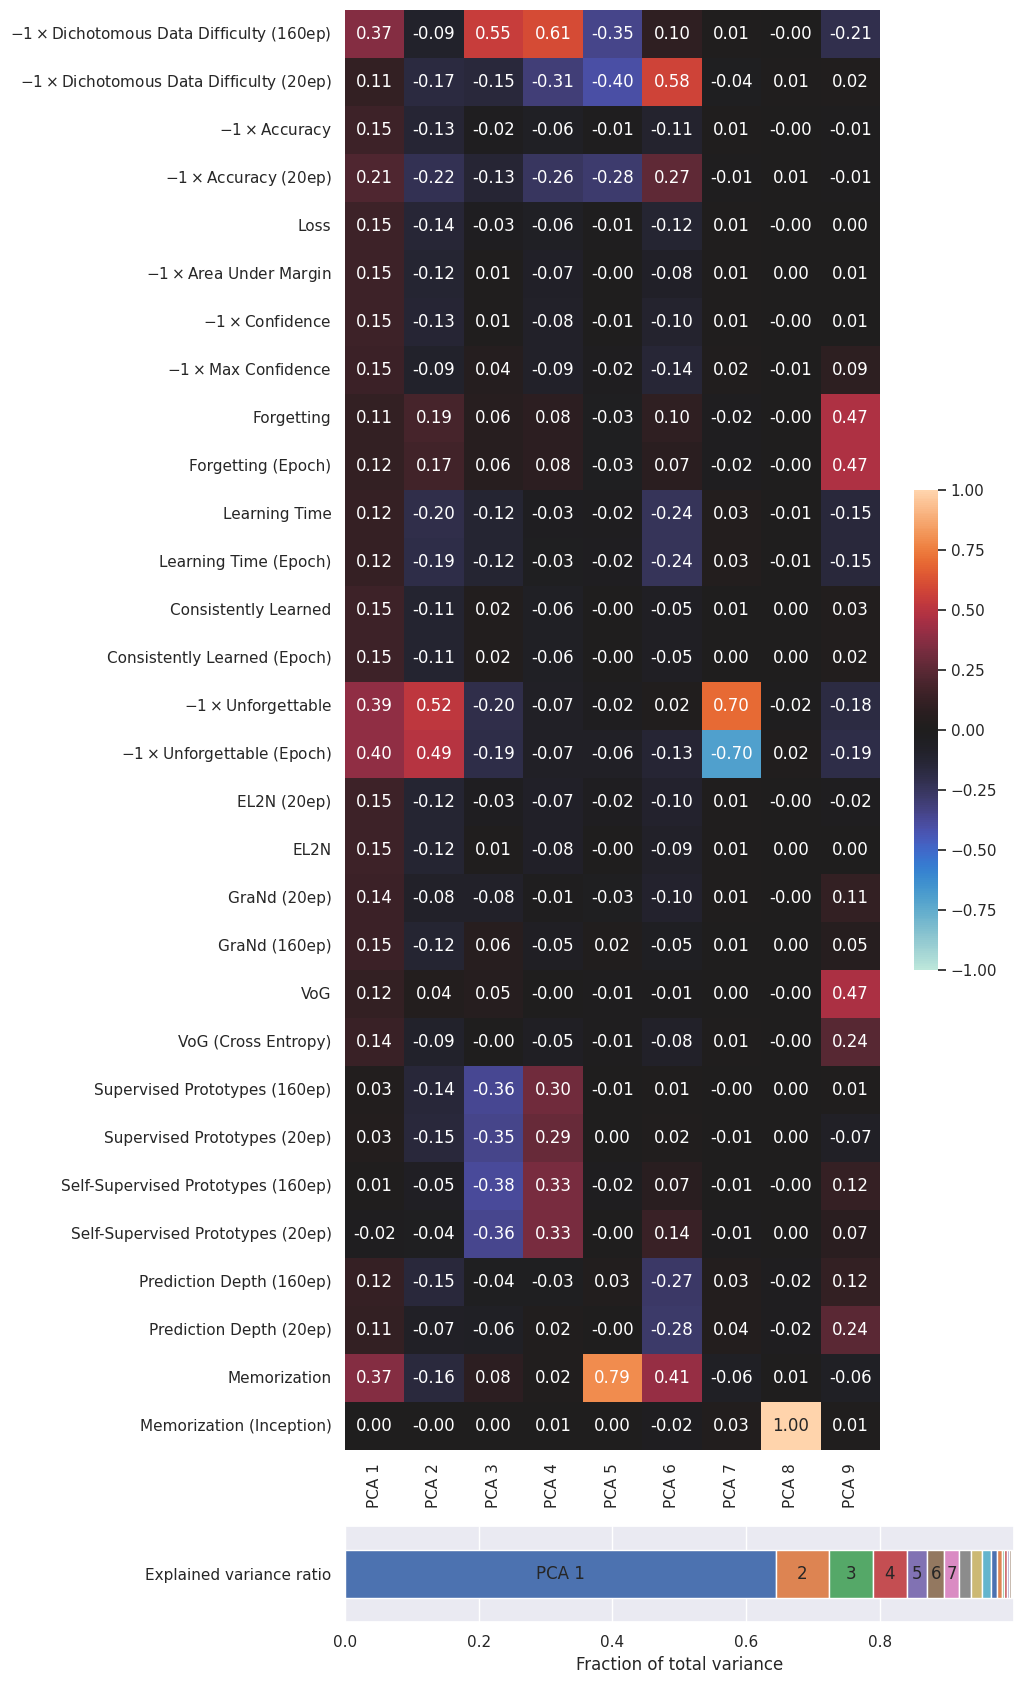

Saving figure to ../outputs/plots/pca/CIFAR-100-ResNet-20_std_pca.pdf


<Figure size 640x480 with 0 Axes>

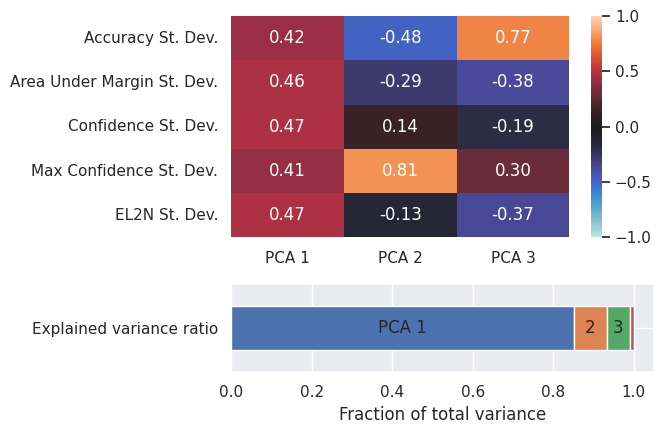

Saving figure to ../outputs/plots/pca/CIFAR-100-ResNet-20_runstd_pca.pdf


<Figure size 640x480 with 0 Axes>

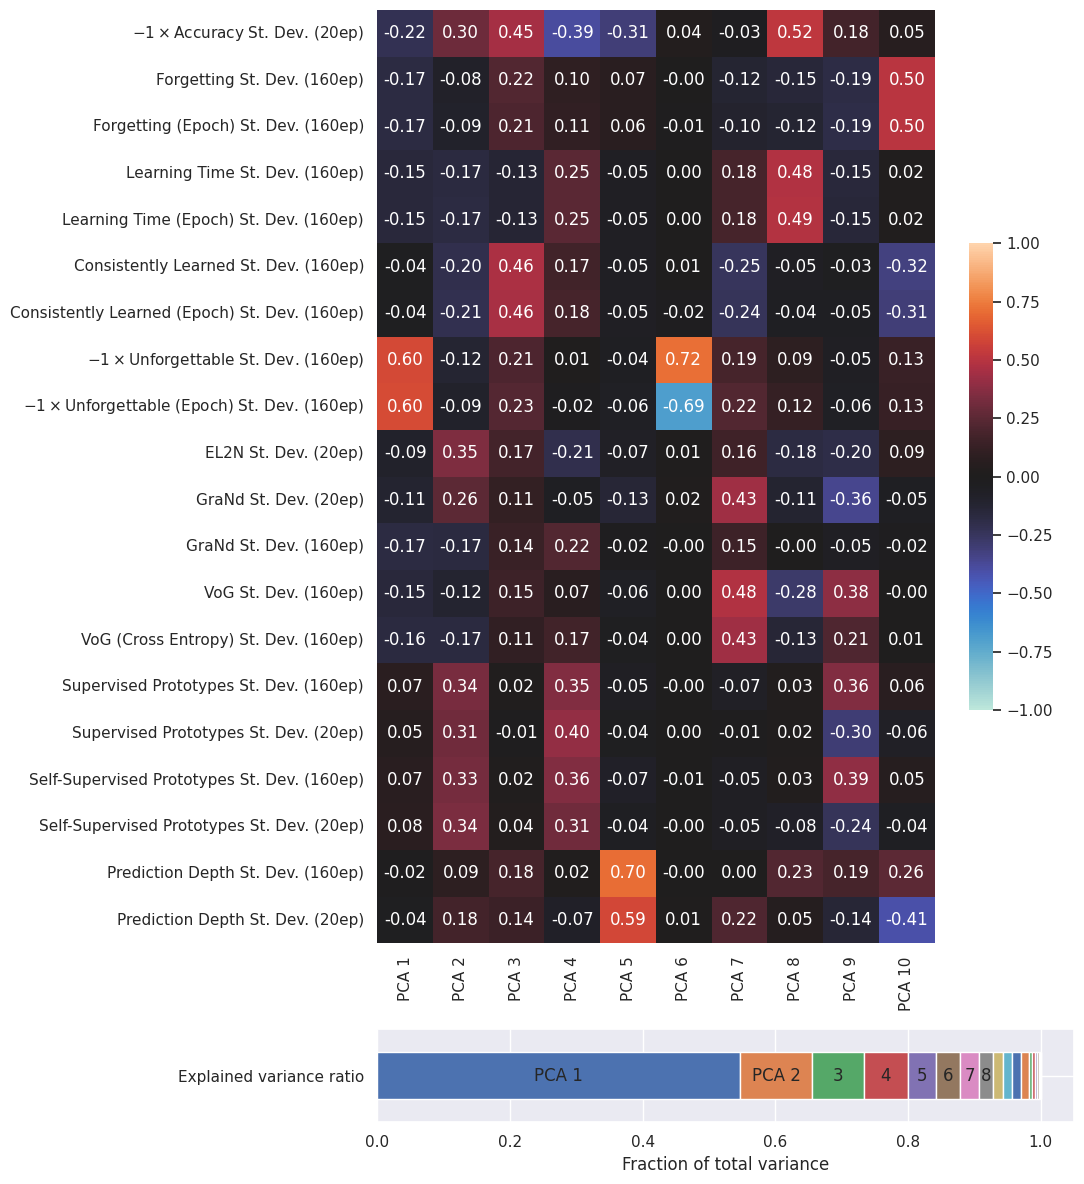

Columns: [Path, Replicate, Epoch, Method, Short Name, Full Name, Type, key, array, is_fuzzed, is_inverted]
Index: []
Columns: [Path, Replicate, Epoch, Method, Short Name, Full Name, Type, key, array, is_fuzzed, is_inverted]
Index: []
Columns: [Path, Replicate, Epoch, Method, Short Name, Full Name, Type, key, array, is_fuzzed, is_inverted]
Index: []
Columns: [Path, Replicate, Epoch, Method, Short Name, Full Name, Type, key, array, is_fuzzed, is_inverted]
Index: []
Columns: [Path, Replicate, Epoch, Method, Short Name, Full Name, Type, key, array, is_fuzzed, is_inverted]
Index: []
Columns: [Path, Replicate, Epoch, Method, Short Name, Full Name, Type, key, array, is_fuzzed, is_inverted]
Index: []
Saving figure to ../outputs/plots/pca/CIFAR-100-ResNet-20_all_plus_std_pca.pdf


<Figure size 640x480 with 0 Axes>

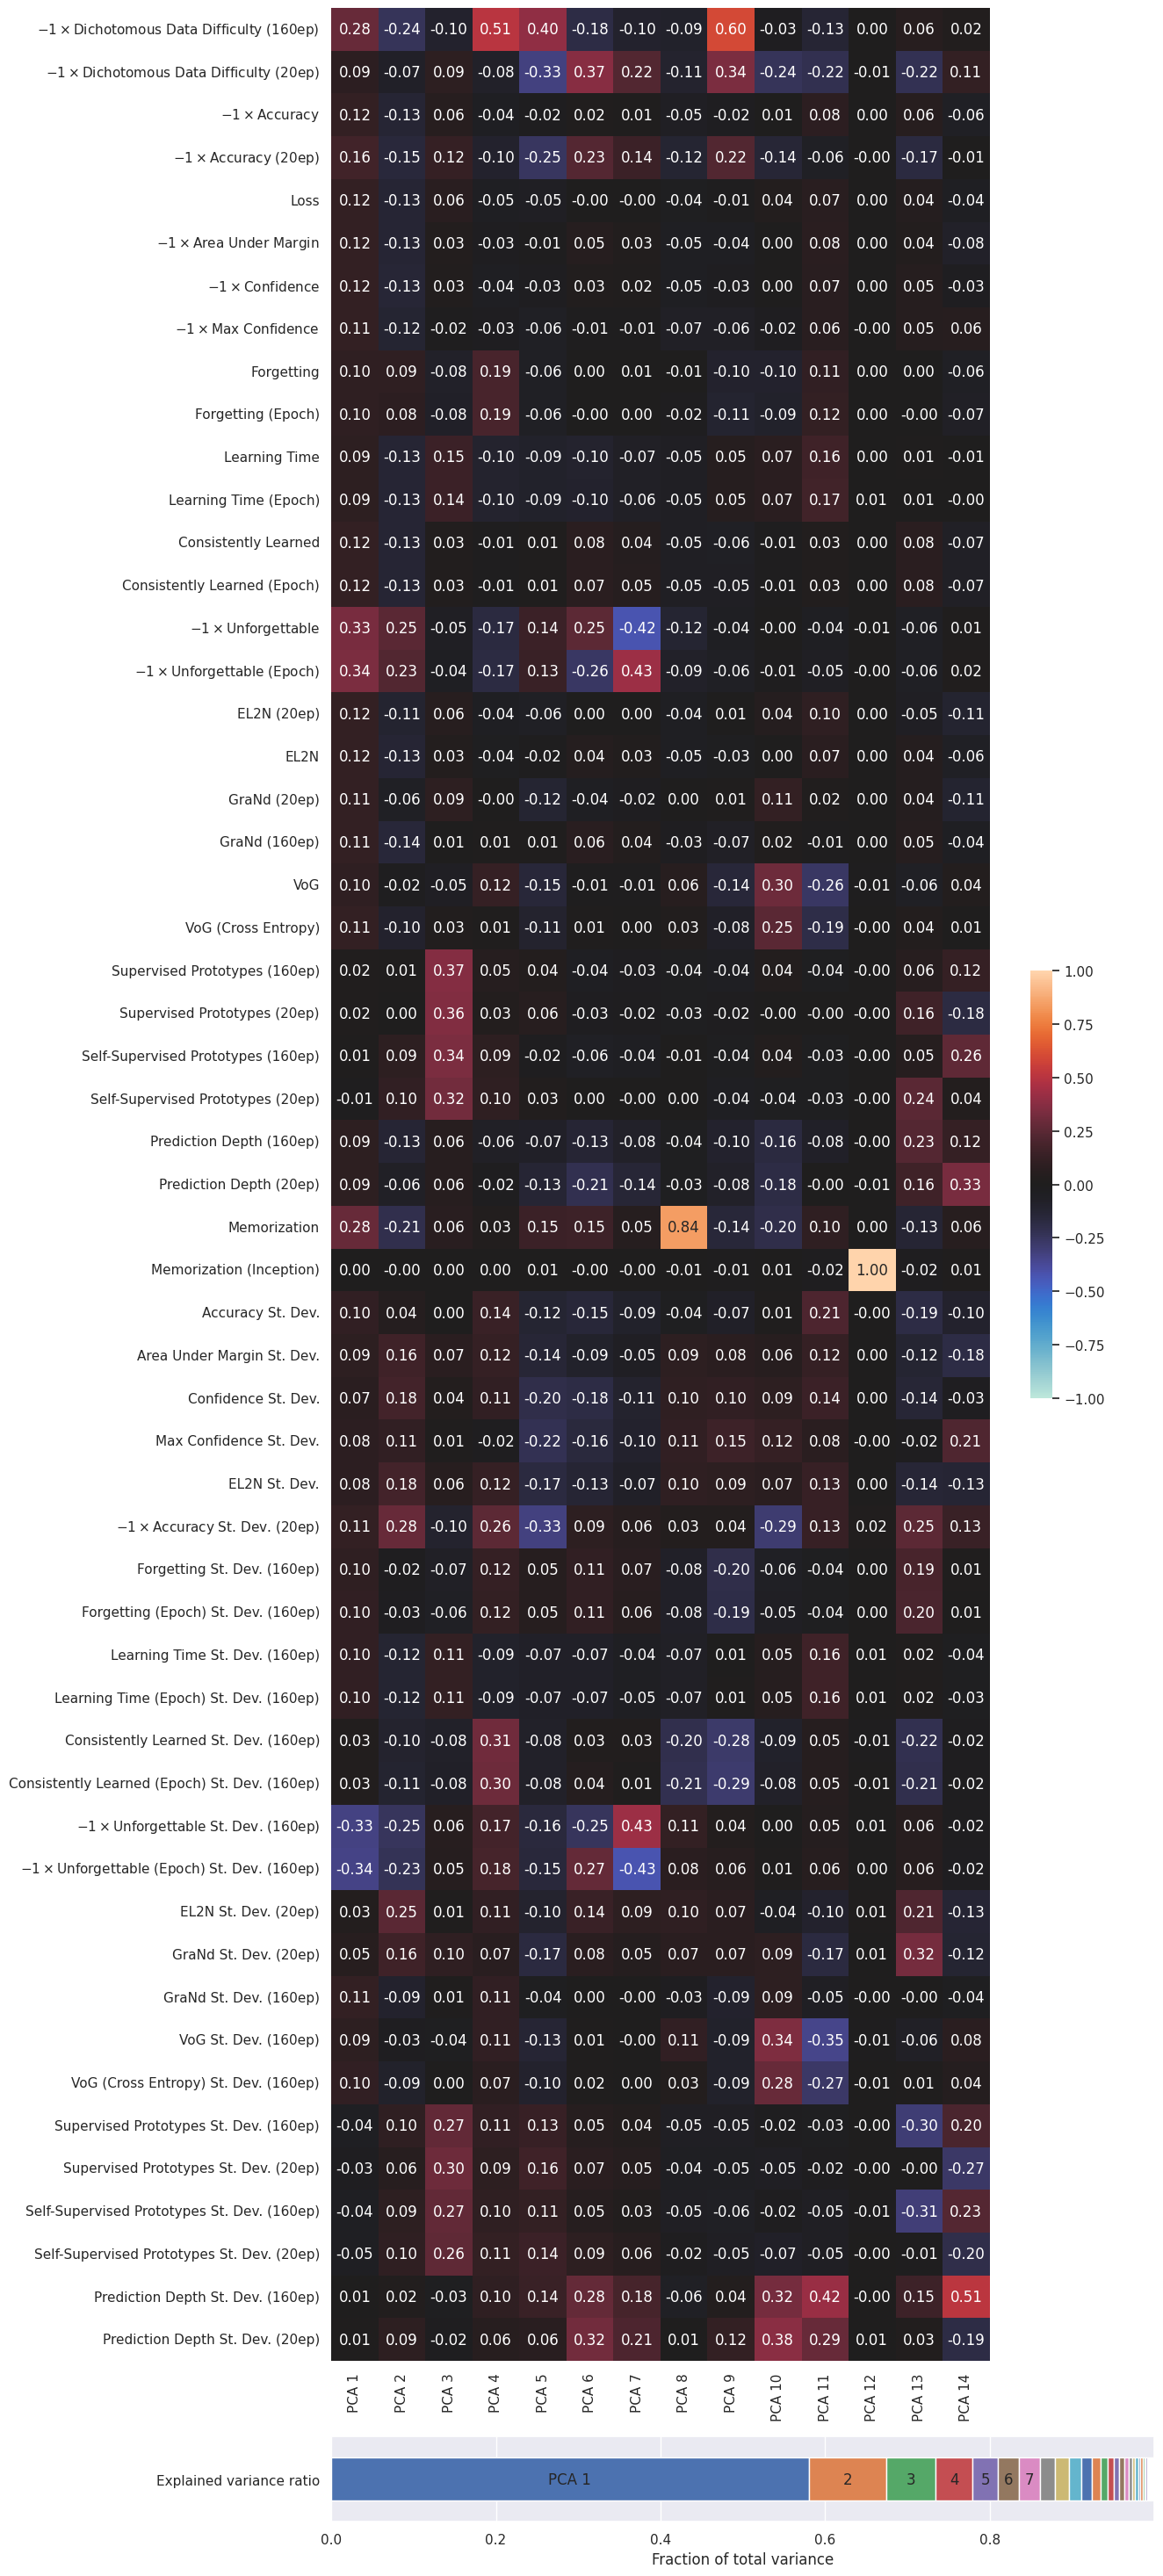

<Figure size 640x480 with 0 Axes>

In [4]:
def get_std_equivalents(score_df, attr_dict, include_std_over_runs=False):
    new_attrs = []
    for attrs in attr_dict:
        new_dict = dict(attrs)
        new_dict["Type"] = "St. Dev."
        if include_std_over_runs:
            new_dict["Method"] = "Ensemble"
        subset = filter_df(score_df, new_dict)
        if len(subset) == 1:
            new_attrs.append(new_dict)
    return new_attrs


for _, model_row in model_df.iterrows():
    print(model_row)
    sanity_checks(model_row["path"])
    task_name = model_row["Task"]

    score_df = get_score_df(model_row, n_replicates=N_RUNS, get_precomputed=True)
    score_df = score_df[score_df["Epoch"] != 0]

    df = get_scores(score_df, n_examples=N_EXAMPLES, fuzz_by=0)
    training_loss = aggregate_steps(df[df["key"] == "loss"])
    training_loss["Epoch"] = training_loss["Epoch"].apply(max)
    run_agg = aggregate_runs(df, include_std=True)
    df = pd.concat([df, training_loss, run_agg[run_agg["Type"] != ""]])

    SELECTED_STDS = get_std_equivalents(df, SELECTED_SCORES)
    ALL_STDS = get_std_equivalents(df, ALL_SCORES)
    SELECTED_RUN_STDS = get_std_equivalents(df, SELECTED_SCORES, include_std_over_runs=True)
    ALL_RUN_STDS = get_std_equivalents(df, ALL_SCORES, include_std_over_runs=True)
    selected_scores = [
        ("_selected", SELECTED_SCORES),
        ("_selected_plus_std", SELECTED_SCORES + SELECTED_STDS),
        ("_selected_plus_std", SELECTED_SCORES + SELECTED_STDS + SELECTED_RUN_STDS),
        ("", ALL_SCORES),
        ("_std", ALL_STDS),
        ("_runstd", ALL_RUN_STDS),
        ("_all_plus_std", ALL_SCORES + ALL_STDS + ALL_RUN_STDS),
    ]

    for name, attrs in selected_scores:
        scores = list(get_selected_scores(df, attrs, strict=False))
        plot_pca(scores, name=task_name + name)